In [1]:
import subprocess
subprocess.run(["ffmpeg", "-version"], check=True)
print("ffmpeg is callable from Python ✅")


ffmpeg is callable from Python ✅


In [ ]:
import yt_dlp

url = "https://www.youtube.com/watch?v=eRWzYPUJsvc"
out_file = "onboard.mp4"

ydl_opts = {
    "format": "bestvideo[ext=mp4]+bestaudio[ext=m4a]/mp4", 
    "outtmpl": out_file,
}

with yt_dlp.YoutubeDL(ydl_opts) as ydl:
    ydl.download([url])

print("Downloaded to", out_file)


[youtube] Extracting URL: https://www.youtube.com/watch?v=eRWzYPUJsvc
[youtube] eRWzYPUJsvc: Downloading webpage
[youtube] eRWzYPUJsvc: Downloading tv simply player API JSON
[youtube] eRWzYPUJsvc: Downloading tv client config
[youtube] eRWzYPUJsvc: Downloading tv player API JSON
[youtube] eRWzYPUJsvc: Downloading player 0004de42-main
[info] eRWzYPUJsvc: Downloading 1 format(s): 399+140
[download] Sleeping 2.00 seconds as required by the site...
[download] Destination: onboard.f399.mp4
[download] 100% of   50.93MiB in 00:00:02 at 22.35MiB/s    
[download] Destination: onboard.f140.m4a
[download] 100% of    2.08MiB in 00:00:00 at 9.86MiB/s   
[Merger] Merging formats into "onboard.mp4"
Deleting original file onboard.f140.m4a (pass -k to keep)
Deleting original file onboard.f399.mp4 (pass -k to keep)
Downloaded to onboard.mp4


In [15]:
from pathlib import Path

# ---- EDIT THESE TWO ----
from pathlib import Path

INPUT_VIDEO = r"E:\video\data\onboard.mp4"   # full path
OUT_DIR     = r"E:\video\data"

PREFERRED_FFMPEG = ""   # use the one found on PATH
               # all outputs go here

# ffmpeg path (uses short folder you set up). If this file doesn’t exist, we’ll fallback to "ffmpeg" on PATH.
PREFERRED_FFMPEG = r"E:\tools\ffmpeg\bin\ffmpeg.exe"

print("INPUT_VIDEO:", INPUT_VIDEO)
print("OUT_DIR    :", OUT_DIR)
print("FFMPEG     :", PREFERRED_FFMPEG, "| exists:", Path(PREFERRED_FFMPEG).exists())
Path(OUT_DIR).mkdir(parents=True, exist_ok=True)


INPUT_VIDEO: E:\video\data\onboard.mp4
OUT_DIR    : E:\video\data
FFMPEG     : E:\tools\ffmpeg\bin\ffmpeg.exe | exists: False


In [16]:
import subprocess, shutil
from pathlib import Path

def find_ffmpeg(preferred: str = "") -> str:
    # if user gave a full path and it exists
    if preferred and Path(preferred).exists():
        try:
            subprocess.run([preferred, "-version"], stdout=subprocess.PIPE, stderr=subprocess.PIPE, check=True)
            print("✅ Using preferred ffmpeg:", preferred)
            return preferred
        except Exception as e:
            print("⚠️ Preferred ffmpeg failed:", e)

    # try system PATH
    exe = shutil.which("ffmpeg")
    if exe:
        try:
            subprocess.run([exe, "-version"], stdout=subprocess.PIPE, stderr=subprocess.PIPE, check=True)
            print("✅ Using ffmpeg from PATH:", exe)
            return exe
        except Exception as e:
            print("⚠️ PATH ffmpeg failed:", e)

    raise FileNotFoundError("❌ No working ffmpeg found. Please check your installation.")

# run the check
ffmpeg_bin = find_ffmpeg(PREFERRED_FFMPEG)


✅ Using ffmpeg from PATH: E:\conda\envs\verbatims\Library\bin\ffmpeg.EXE


In [17]:
import subprocess
from typing import List
from pathlib import Path

def _ffmpeg_cmd(preferred: str) -> str:
    p = Path(preferred)
    if preferred and p.exists():
        return preferred
    return "ffmpeg"  # rely on PATH

def _run(cmd: List[str]) -> None:
    print(">>>", " ".join(cmd))
    subprocess.run(cmd, check=True)


In [18]:
import os, shutil
from typing import Dict

def preprocess_video(
    input_path: str,
    out_dir: str,
    width: int = 512,
    height: int = 144,
    fps: int = 24,
    chunk_seconds: int = 5,
    mask_bottom_half: bool = True,
    crf: int = 18,
    preset: str = "veryfast",
    preferred_ffmpeg: str = ""
) -> Dict[str, str]:
    """
    Returns dict with 'resized', 'masked', 'chunks_dir'
    """
    ffmpeg = _ffmpeg_cmd(preferred_ffmpeg)
    inp = Path(input_path)
    out = Path(out_dir)
    out.mkdir(parents=True, exist_ok=True)

    # 1) Resize + FPS
    resized = out / f"{inp.stem}_resized_{width}x{height}_{fps}fps.mp4"
    _run([
        ffmpeg, "-y", "-i", str(inp),
        "-vf", f"scale={width}:{height}",
        "-r", str(fps),
        "-c:v", "libx264", "-crf", str(crf), "-preset", preset,
        str(resized)
    ])

    # 2) Mask bottom half (removes static car region)
    if mask_bottom_half:
        y = height // 2
        h = height - y
        drawbox = f"drawbox=x=0:y={y}:w={width}:h={h}:color=black:t=fill"
        masked = out / f"{inp.stem}_masked.mp4"
        _run([
            ffmpeg, "-y", "-i", str(resized),
            "-vf", drawbox,
            "-c:v", "libx264", "-crf", str(crf), "-preset", preset,
            str(masked)
        ])
    else:
        masked = resized

    # 3) Chunk into ~5s segments (copy for speed; new timestamps)
    chunks_dir = out / "chunks"
    if chunks_dir.exists():
        shutil.rmtree(chunks_dir)
    chunks_dir.mkdir(parents=True, exist_ok=True)

    _run([
        ffmpeg, "-y", "-i", str(masked),
        "-c", "copy", "-map", "0",
        "-segment_time", str(chunk_seconds),
        "-reset_timestamps", "1",
        "-f", "segment", str(chunks_dir / "chunk_%03d.mp4")
    ])

    return {"resized": str(resized), "masked": str(masked), "chunks_dir": str(chunks_dir)}


In [19]:
assert Path(INPUT_VIDEO).exists(), f"INPUT_VIDEO not found: {INPUT_VIDEO}"

paths = preprocess_video(
    input_path=INPUT_VIDEO,
    out_dir=OUT_DIR,
    width=512, height=144, fps=24,
    chunk_seconds=5,
    mask_bottom_half=True,
    preferred_ffmpeg=PREFERRED_FFMPEG
)
paths


>>> ffmpeg -y -i E:\video\data\onboard.mp4 -vf scale=512:144 -r 24 -c:v libx264 -crf 18 -preset veryfast E:\video\data\onboard_resized_512x144_24fps.mp4
>>> ffmpeg -y -i E:\video\data\onboard_resized_512x144_24fps.mp4 -vf drawbox=x=0:y=72:w=512:h=72:color=black:t=fill -c:v libx264 -crf 18 -preset veryfast E:\video\data\onboard_masked.mp4
>>> ffmpeg -y -i E:\video\data\onboard_masked.mp4 -c copy -map 0 -segment_time 5 -reset_timestamps 1 -f segment E:\video\data\chunks\chunk_%03d.mp4


{'resized': 'E:\\video\\data\\onboard_resized_512x144_24fps.mp4',
 'masked': 'E:\\video\\data\\onboard_masked.mp4',
 'chunks_dir': 'E:\\video\\data\\chunks'}

In [20]:
from pathlib import Path
import cv2

chunk_paths = sorted(Path(paths["chunks_dir"]).glob("chunk_*.mp4"))
print("Found chunks:", len(chunk_paths))
for p in chunk_paths[:5]:
    cap = cv2.VideoCapture(str(p))
    n = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    fps = cap.get(cv2.CAP_PROP_FPS) or 24.0
    cap.release()
    print(p.name, "frames:", n, "approx seconds:", round(n/max(fps,1),2))


Found chunks: 14
chunk_000.mp4 frames: 250 approx seconds: 10.42
chunk_001.mp4 frames: 250 approx seconds: 10.42
chunk_002.mp4 frames: 224 approx seconds: 9.33
chunk_003.mp4 frames: 250 approx seconds: 10.42
chunk_004.mp4 frames: 250 approx seconds: 10.42


In [ ]:
import numpy as np
import cv2
from typing import Tuple, List

def suggest_cut_points_on_straights(
    video_path: str,
    fps_sample: int = 6,
    window_sec: float = 1.0,
    mag_thresh: float = 0.6,
) -> List[int]:
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        raise RuntimeError(f"Cannot open: {video_path}")

    src_fps = cap.get(cv2.CAP_PROP_FPS) or 24.0
    step = max(1, int(src_fps // fps_sample))
    frames = []
    ok, prev = cap.read()
    idx = 0
    while ok:
        if idx % step == 0:
            frames.append(cv2.cvtColor(prev, cv2.COLOR_BGR2GRAY))
        ok, prev = cap.read()
        idx += 1
    cap.release()
    if len(frames) < 2:
        return []

    mags = []
    for i in range(1, len(frames)):
        flow = cv2.calcOpticalFlowFarneback(frames[i-1], frames[i],
                                            None, 0.5, 3, 15, 3, 5, 1.2, 0)
        mag, _ = cv2.cartToPolar(flow[...,0], flow[...,1])
        mags.append(float(np.mean(mag)))

    mags = np.array(mags)
    w = max(1, int(window_sec * fps_sample))
    sm = np.convolve(mags, np.ones(w)/w, mode='same')

    cut_points = []
    for i in range(1, len(sm)-1):
        if sm[i] < sm[i-1] and sm[i] < sm[i+1] and sm[i] < mag_thresh:
            cut_points.append(i * step)
    return cut_points

def smart_chunk_by_straights(
    input_path: str,
    desired_chunk_seconds: int = 5,
    min_chunk_seconds: int = 3,
) -> List[Tuple[int, int]]:
    cap = cv2.VideoCapture(input_path)
    if not cap.isOpened():
        raise RuntimeError(f"Cannot open: {input_path}")
    fps = cap.get(cv2.CAP_PROP_FPS) or 24.0
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    cap.release()

    straight_cuts = set(suggest_cut_points_on_straights(input_path))
    target = int(desired_chunk_seconds * fps)
    min_frames = int(min_chunk_seconds * fps)

    intervals = []
    start = 0
    while start < total_frames:
        end = min(total_frames, start + target)
        window = int(1.5 * fps)
        best = None
        for j in range(end, max(start + min_frames, end - window), -1):
            if j in straight_cuts:
                best = j; break
        if best is None:
            best = end
        intervals.append((start, best))
        start = best
    return intervals


In [ ]:
from typing import List, Tuple

def trim_intervals_with_ffmpeg(
    input_path: str,
    intervals: List[Tuple[int, int]],
    out_dir: str,
    fps: float = None,
    preferred_ffmpeg: str = ""
) -> List[str]:
    ffmpeg = _ffmpeg_cmd(preferred_ffmpeg)
    inp = Path(input_path)
    outd = Path(out_dir)
    outd.mkdir(parents=True, exist_ok=True)

    if fps is None:
        cap = cv2.VideoCapture(input_path)
        fps = cap.get(cv2.CAP_PROP_FPS) or 24.0
        cap.release()

    outputs = []
    for k, (s, e) in enumerate(intervals):
        ss = s / fps
        to = e / fps
        outp = outd / f"smart_{k:03d}.mp4"
        _run([
            ffmpeg, "-y", "-i", str(inp),
            "-ss", f"{ss:.3f}", "-to", f"{to:.3f}",
            "-c:v", "libx264", "-crf", "18", "-preset", "veryfast",
            str(outp)
        ])
        outputs.append(str(outp))
    return outputs


In [23]:
intervals = smart_chunk_by_straights(
    input_path=paths["masked"], desired_chunk_seconds=5, min_chunk_seconds=3
)
print("Intervals (first few):", intervals[:5], " ... total:", len(intervals))

SMART_DIR = str(Path(OUT_DIR) / "smart_chunks")
smart_paths = trim_intervals_with_ffmpeg(paths["masked"], intervals, SMART_DIR, preferred_ffmpeg=PREFERRED_FFMPEG)
print("Smart chunks (first few):", smart_paths[:5], " ... total:", len(smart_paths))


Intervals (first few): [(0, 120), (120, 240), (240, 360), (360, 480), (480, 600)]  ... total: 27
>>> ffmpeg -y -i E:\video\data\onboard_masked.mp4 -ss 0.000 -to 5.000 -c:v libx264 -crf 18 -preset veryfast E:\video\data\smart_chunks\smart_000.mp4
>>> ffmpeg -y -i E:\video\data\onboard_masked.mp4 -ss 5.000 -to 10.000 -c:v libx264 -crf 18 -preset veryfast E:\video\data\smart_chunks\smart_001.mp4
>>> ffmpeg -y -i E:\video\data\onboard_masked.mp4 -ss 10.000 -to 15.000 -c:v libx264 -crf 18 -preset veryfast E:\video\data\smart_chunks\smart_002.mp4
>>> ffmpeg -y -i E:\video\data\onboard_masked.mp4 -ss 15.000 -to 20.000 -c:v libx264 -crf 18 -preset veryfast E:\video\data\smart_chunks\smart_003.mp4
>>> ffmpeg -y -i E:\video\data\onboard_masked.mp4 -ss 20.000 -to 25.000 -c:v libx264 -crf 18 -preset veryfast E:\video\data\smart_chunks\smart_004.mp4
>>> ffmpeg -y -i E:\video\data\onboard_masked.mp4 -ss 25.000 -to 30.000 -c:v libx264 -crf 18 -preset veryfast E:\video\data\smart_chunks\smart_005.mp4


First few regular chunks:
chunk_000.mp4


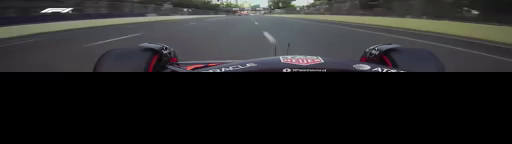

chunk_001.mp4


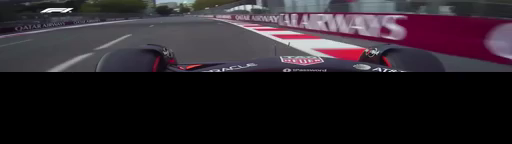

chunk_002.mp4


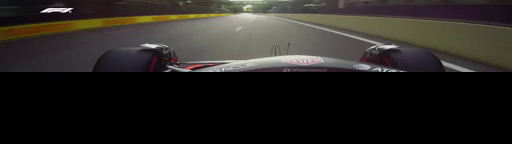


First few smart chunks:
smart_000.mp4


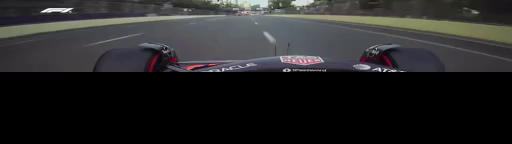

smart_001.mp4


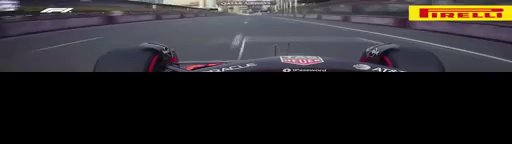

smart_002.mp4


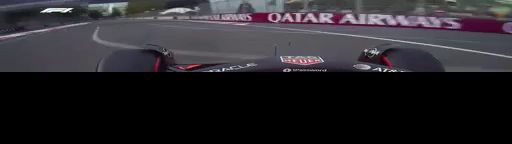

In [24]:
import cv2
from IPython.display import display
from PIL import Image

def show_first_frame(video_path):
    cap = cv2.VideoCapture(video_path)
    ok, frame = cap.read()
    cap.release()
    if not ok:
        print("Could not read:", video_path); return
    rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    display(Image.fromarray(rgb))

print("First few regular chunks:")
for p in sorted(Path(paths["chunks_dir"]).glob("chunk_*.mp4"))[:3]:
    print(p.name)
    show_first_frame(str(p))

print("\nFirst few smart chunks:")
for p in sorted(Path(SMART_DIR).glob("smart_*.mp4"))[:3]:
    print(Path(p).name)
    show_first_frame(str(p))


Regular chunks:
chunk_000.mp4


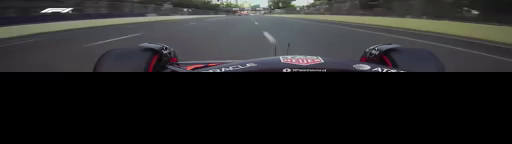

chunk_001.mp4


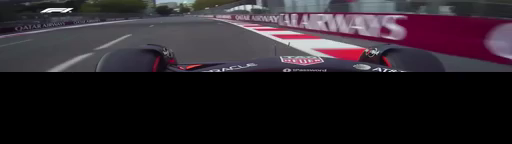

chunk_002.mp4


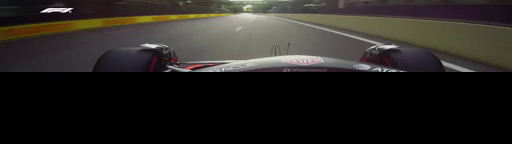


Smart chunks:
smart_000.mp4


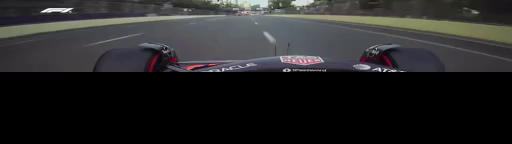

smart_001.mp4


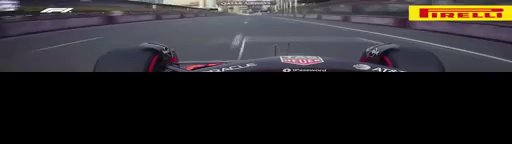

smart_002.mp4


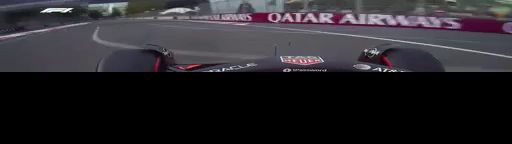

In [25]:
import cv2
from IPython.display import display
from PIL import Image

def show_first_frame(video_path):
    cap = cv2.VideoCapture(video_path)
    ok, frame = cap.read()
    cap.release()
    if not ok:
        print("Could not read:", video_path); return
    rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    display(Image.fromarray(rgb))

print("Regular chunks:")
for p in sorted(Path(paths["chunks_dir"]).glob("chunk_*.mp4"))[:3]:
    print(p.name)
    show_first_frame(str(p))

print("\nSmart chunks:")
for p in sorted(Path(SMART_DIR).glob("*.mp4"))[:3]:
    print(Path(p).name)
    show_first_frame(str(p))


In [ ]:
import subprocess
from pathlib import Path

def extract_frames_from_video(video_path: str, out_dir: str, ffmpeg_bin: str):
    """
    Extracts frames from a video into out_dir/frame_000001.jpg
    """
    video_path = Path(video_path)
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    cmd = [
        ffmpeg_bin,
        "-y",                     
        "-i", str(video_path),    
        str(out_dir / "frame_%06d.jpg")   
    ]

    print(">>> Extracting frames for:", video_path.name)
    subprocess.run(cmd, check=True)
    return out_dir


In [ ]:
E:\video\priliminary\preprocess.ipynb

In [ ]:
import os, shutil
import subprocess
from typing import Dict
from pathlib import Path

def _ffmpeg_cmd(preferred: str) -> str:
    p = Path(preferred)
    if preferred and p.exists():
        return preferred
    return "ffmpeg"  

def _run(cmd):
    print(">>>", " ".join(map(str, cmd)))
    subprocess.run(cmd, check=True)

def preprocess_video(
    input_path: str,
    out_dir: str,
    width: int = 512,
    height: int = 144,
    fps: int = 24,
    chunk_seconds: int = 5,
    mask_bottom_half: bool = True,
    crf: int = 18,
    preset: str = "veryfast",
    preferred_ffmpeg: str = "",
    max_duration_sec: int | None = None, 
) -> Dict[str, str]:
    
    ffmpeg = _ffmpeg_cmd(preferred_ffmpeg)
    inp = Path(input_path)
    out = Path(out_dir)
    out.mkdir(parents=True, exist_ok=True)

    resized = out / f"{inp.stem}_resized_{width}x{height}_{fps}fps.mp4"

    resize_cmd = [
        ffmpeg, "-y", "-i", str(inp),
        "-vf", f"scale={width}:{height}",
        "-r", str(fps),
    ]
    if max_duration_sec is not None:
        resize_cmd += ["-t", str(max_duration_sec)]  # 👈 trim to first N seconds

    resize_cmd += [
        "-c:v", "libx264", "-crf", str(crf), "-preset", preset,
        str(resized)
    ]
    _run(resize_cmd)

    if mask_bottom_half:
        y = height // 2
        h = height - y
        drawbox = f"drawbox=x=0:y={y}:w={width}:h={h}:color=black:t=fill"
        masked = out / f"{inp.stem}_masked.mp4"
        _run([
            ffmpeg, "-y", "-i", str(resized),
            "-vf", drawbox,
            "-c:v", "libx264", "-crf", str(crf), "-preset", preset,
            str(masked)
        ])
    else:
        masked = resized

    chunks_dir = out / "chunks"
    if chunks_dir.exists():
        shutil.rmtree(chunks_dir)
    chunks_dir.mkdir(parents=True, exist_ok=True)

    _run([
        ffmpeg, "-y", "-i", str(masked),
        "-c", "copy", "-map", "0",
        "-segment_time", str(chunk_seconds),
        "-reset_timestamps", "1",
        "-f", "segment", str(chunks_dir / "chunk_%03d.mp4")
    ])

    return {
        "resized": str(resized),
        "masked": str(masked),
        "chunks_dir": str(chunks_dir),
    }


In [4]:
from pathlib import Path

INPUT_VIDEO = r"E:\video\data\onboard.mp4"
OUT_DIR     = r"E:\video\data"
PREFERRED_FFMPEG = r"E:\tools\ffmpeg\bin\ffmpeg.exe"

print("INPUT_VIDEO:", INPUT_VIDEO)
print("OUT_DIR    :", OUT_DIR)
print("FFMPEG     :", PREFERRED_FFMPEG, "| exists:", Path(PREFERRED_FFMPEG).exists())
Path(OUT_DIR).mkdir(parents=True, exist_ok=True)


INPUT_VIDEO: E:\video\data\onboard.mp4
OUT_DIR    : E:\video\data
FFMPEG     : E:\tools\ffmpeg\bin\ffmpeg.exe | exists: False


In [ ]:
paths = preprocess_video(
    input_path=INPUT_VIDEO,
    out_dir=OUT_DIR,
    width=512, height=144, fps=24,
    chunk_seconds=5,
    mask_bottom_half=True,
    preferred_ffmpeg=PREFERRED_FFMPEG,
    max_duration_sec=110   
)


>>> ffmpeg -y -i E:\video\data\onboard.mp4 -vf scale=512:144 -r 24 -t 110 -c:v libx264 -crf 18 -preset veryfast E:\video\data\onboard_resized_512x144_24fps.mp4
>>> ffmpeg -y -i E:\video\data\onboard_resized_512x144_24fps.mp4 -vf drawbox=x=0:y=72:w=512:h=72:color=black:t=fill -c:v libx264 -crf 18 -preset veryfast E:\video\data\onboard_masked.mp4
>>> ffmpeg -y -i E:\video\data\onboard_masked.mp4 -c copy -map 0 -segment_time 5 -reset_timestamps 1 -f segment E:\video\data\chunks\chunk_%03d.mp4


In [ ]:
from pathlib import Path

SMART_DIR = Path(r"E:\video\data\smart_chunks")

keep_min, keep_max = 1, 22

smart_videos = []

for f in sorted(SMART_DIR.glob("smart_*.mp4")):
    try:
        num = int(f.stem.split("_")[1])   
    except (IndexError, ValueError):
        print("Skipping (name not matching smart_XXX):", f)
        continue

    if keep_min <= num <= keep_max:
        smart_videos.append(f)
        print("Keeping:", f.name)
    else:
        print("Ignoring:", f.name)

print("\nTotal smart chunks used:", len(smart_videos))


Ignoring: smart_000.mp4
Keeping: smart_001.mp4
Keeping: smart_002.mp4
Keeping: smart_003.mp4
Keeping: smart_004.mp4
Keeping: smart_005.mp4
Keeping: smart_006.mp4
Keeping: smart_007.mp4
Keeping: smart_008.mp4
Keeping: smart_009.mp4
Keeping: smart_010.mp4
Keeping: smart_011.mp4
Keeping: smart_012.mp4
Keeping: smart_013.mp4
Keeping: smart_014.mp4
Keeping: smart_015.mp4
Keeping: smart_016.mp4
Keeping: smart_017.mp4
Keeping: smart_018.mp4
Keeping: smart_019.mp4
Keeping: smart_020.mp4
Keeping: smart_021.mp4
Keeping: smart_022.mp4
Ignoring: smart_023.mp4
Ignoring: smart_024.mp4
Ignoring: smart_025.mp4
Ignoring: smart_026.mp4

Total smart chunks used: 22


In [ ]:
import subprocess
from pathlib import Path

def extract_frames_from_video(video_path: str, out_dir: str, ffmpeg_bin: str):
    """
    Extracts frames from a video into out_dir/frame_000001.jpg, frame_000002.jpg, ...
    """
    video_path = Path(video_path)
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    cmd = [
        ffmpeg_bin,
        "-y",                     
        "-i", str(video_path),    
        str(out_dir / "frame_%06d.jpg")  
    ]

    print(">>> Extracting frames for:", video_path.name)
    subprocess.run(cmd, check=True)
    return out_dir


In [3]:
from pathlib import Path
import numpy as np
import torch

from dust3r.inference import inference
from dust3r.model import AsymmetricCroCo3DStereo
from dust3r.utils.image import load_images
from dust3r.image_pairs import make_pairs
from dust3r.cloud_opt import global_aligner, GlobalAlignerMode

import open3d as o3d


ModuleNotFoundError: No module named 'dust3r'

In [2]:
import sys
print(sys.executable)


e:\video\droid_env\python.exe


In [4]:
from dust3r.inference import inference
from dust3r.model import AsymmetricCroCo3DStereo
from dust3r.utils.image import load_images
from dust3r.image_pairs import make_pairs
from dust3r.cloud_opt import global_aligner, GlobalAlignerMode


ModuleNotFoundError: No module named 'dust3r'

In [ ]:
import sys
print("Python exe:", sys.executable)  
sys.path.append(r"E:\video\dust3r")

# Now try the imports
from dust3r.inference import inference
from dust3r.model import AsymmetricCroCo3DStereo
from dust3r.utils.image import load_images
from dust3r.image_pairs import make_pairs
from dust3r.cloud_opt import global_aligner, GlobalAlignerMode

print("✅ DUSt3R imports OK")


Python exe: e:\video\droid_env\python.exe
Warning, cannot find cuda-compiled version of RoPE2D, using a slow pytorch version instead


ImportError: cannot import name 'cache' from 'functools' (e:\video\droid_env\lib\functools.py)

In [1]:
import sys
print(sys.executable)


e:\video\dust_env\python.exe


In [ ]:
import sys
sys.path.append(r"E:\video\dust3r")  # repo root

from dust3r.inference import inference
from dust3r.model import AsymmetricCroCo3DStereo
from dust3r.utils.image import load_images
from dust3r.image_pairs import make_pairs
from dust3r.cloud_opt import global_aligner, GlobalAlignerMode

print("DUSt3R imports OK")


Warning, cannot find cuda-compiled version of RoPE2D, using a slow pytorch version instead
✅ DUSt3R imports OK


E:\video\dust3r\dust3r\cloud_opt\base_opt.py:275: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  @torch.cuda.amp.autocast(enabled=False)


In [ ]:
from pathlib import Path
import numpy as np
import torch
import open3d as o3d

FRAME_ROOT = Path(r"E:\video\data\smart_chunks")
chunk_id = "smart_010"   
frames_dir = FRAME_ROOT / chunk_id

all_frames = sorted(frames_dir.glob("frame_*.jpg"))
print(chunk_id, "has", len(all_frames), "frames")

max_images = 16  
if len(all_frames) < 3:
    raise RuntimeError("Not enough frames in this chunk")

step = max(1, len(all_frames) // max_images)
selected_paths = [str(p) for p in all_frames[::step][:max_images]]

print("Using", len(selected_paths), "frames:")
for p in selected_paths[:5]:
    print("  ", p)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

model_name = "naver/DUSt3R_ViTLarge_BaseDecoder_512_dpt"
model = AsymmetricCroCo3DStereo.from_pretrained(model_name).to(device)

images = load_images(selected_paths, size=512)
pairs = make_pairs(images, scene_graph='complete', prefilter=None, symmetrize=True)

output = inference(pairs, model, device=device, batch_size=1)
scene = global_aligner(output, device=device, mode=GlobalAlignerMode.PointCloudOptimizer)

loss = scene.compute_global_alignment(init="mst", niter=300, schedule="cosine", lr=0.01)
print("Final alignment loss:", float(loss))

pts3d_list = scene.get_pts3d()
masks = scene.get_masks()

all_pts = []
for pts3d, mask in zip(pts3d_list, masks):
    pts = pts3d[mask].detach().cpu().numpy()
    all_pts.append(pts)

if not all_pts:
    raise RuntimeError("No 3D points found!")

all_pts = np.concatenate(all_pts, axis=0)
print("Total 3D points:", all_pts.shape[0])

pcd = o3d.geometry.PointCloud()
pcd.points = o3d.utility.Vector3dVector(all_pts)

out_ply = FRAME_ROOT.parent / f"dust3r_{chunk_id}.ply"
o3d.io.write_point_cloud(str(out_ply), pcd)
print("Saved point cloud to:", out_ply)

o3d.visualization.draw_geometries([pcd])


Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.
smart_010 has 0 frames


RuntimeError: Not enough frames in this chunk

In [ ]:
import subprocess, shutil
from pathlib import Path

SMART_DIR = Path(r"E:\video\data\smart_chunks")

FRAME_ROOT = Path(r"E:\video\data\dust3r_frames")
FRAME_ROOT.mkdir(parents=True, exist_ok=True)

def find_ffmpeg(preferred: str = "") -> str:
    if preferred and Path(preferred).exists():
        return preferred
    exe = shutil.which("ffmpeg")
    if not exe:
        raise FileNotFoundError("ffmpeg not found. Install it or add to PATH.")
    return exe

ffmpeg_bin = find_ffmpeg(r"E:\tools\ffmpeg\bin\ffmpeg.exe")  # 👈 change if your ffmpeg is elsewhere
print("Using ffmpeg:", ffmpeg_bin)

def extract_frames_from_smart_chunk(chunk_id: str, max_frames: int | None = None):
    """
    Extract frames from E:\video\data\smart_chunks\<chunk_id>.mp4
    into E:\video\data\dust3r_frames\<chunk_id>\frame_000001.jpg ...
    """
    vid_path = SMART_DIR / f"{chunk_id}.mp4"
    if not vid_path.exists():
        raise FileNotFoundError(f"Smart chunk not found: {vid_path}")

    out_dir = FRAME_ROOT / chunk_id
    out_dir.mkdir(parents=True, exist_ok=True)

    cmd = [
        ffmpeg_bin,
        "-y",
        "-i", str(vid_path),
        str(out_dir / "frame_%06d.jpg")
    ]

    print(">>> Extracting frames from", vid_path)
    subprocess.run(cmd, check=True)

    frames = sorted(out_dir.glob("frame_*.jpg"))
    if max_frames is not None and len(frames) > max_frames:
        print(f"Trimming to first {max_frames} frames")
        for f in frames[max_frames:]:
            f.unlink()
        frames = sorted(out_dir.glob("frame_*.jpg"))

    print("Extracted", len(frames), "frames into", out_dir)
    return out_dir


Using ffmpeg: D:\Project_Audio\ffmpeg-7.1-essentials_build\bin\ffmpeg.EXE


In [5]:
chunk_id = "smart_010"  # or "smart_000", "smart_001", etc.
frames_dir = extract_frames_from_smart_chunk(chunk_id, max_frames=None)
print("Frames dir:", frames_dir)


>>> Extracting frames from E:\video\data\smart_chunks\smart_010.mp4
Extracted 120 frames into E:\video\data\dust3r_frames\smart_010
Frames dir: E:\video\data\dust3r_frames\smart_010


In [6]:
from pathlib import Path
print(len(list(frames_dir.glob("frame_*.jpg"))), "frames found")

120 frames found


In [ ]:
from pathlib import Path
import numpy as np
import torch
import open3d as o3d

FRAME_ROOT = Path(r"E:\video\data\dust3r_frames")
chunk_id = "smart_010"   
frames_dir = FRAME_ROOT / chunk_id

all_frames = sorted(frames_dir.glob("frame_*.jpg"))
print(chunk_id, "has", len(all_frames), "frames")

max_images = 16 
if len(all_frames) < 3:
    raise RuntimeError("Not enough frames in this chunk")

step = max(1, len(all_frames) // max_images)
selected_paths = [str(p) for p in all_frames[::step][:max_images]]

print("Using", len(selected_paths), "frames:")
for p in selected_paths[:5]:
    print("  ", p)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

model_name = "naver/DUSt3R_ViTLarge_BaseDecoder_512_dpt"
model = AsymmetricCroCo3DStereo.from_pretrained(model_name).to(device)

images = load_images(selected_paths, size=512)
pairs = make_pairs(images, scene_graph='complete', prefilter=None, symmetrize=True)

output = inference(pairs, model, device=device, batch_size=1)
scene = global_aligner(output, device=device, mode=GlobalAlignerMode.PointCloudOptimizer)

loss = scene.compute_global_alignment(init="mst", niter=300, schedule="cosine", lr=0.01)
print("Final alignment loss:", float(loss))

pts3d_list = scene.get_pts3d()
masks = scene.get_masks()

all_pts = []
for pts3d, mask in zip(pts3d_list, masks):
    pts = pts3d[mask].detach().cpu().numpy()
    all_pts.append(pts)

if not all_pts:
    raise RuntimeError("No 3D points found!")

all_pts = np.concatenate(all_pts, axis=0)
print("Total 3D points:", all_pts.shape[0])

pcd = o3d.geometry.PointCloud()
pcd.points = o3d.utility.Vector3dVector(all_pts)

out_ply = frames_dir.parent.parent / f"dust3r_{chunk_id}.ply"

import os
print("Saving to:", out_ply)
o3d.io.write_point_cloud(str(out_ply), pcd)

o3d.visualization.draw_geometries([pcd])


smart_010 has 120 frames
Using 16 frames:
   E:\video\data\dust3r_frames\smart_010\frame_000001.jpg
   E:\video\data\dust3r_frames\smart_010\frame_000008.jpg
   E:\video\data\dust3r_frames\smart_010\frame_000015.jpg
   E:\video\data\dust3r_frames\smart_010\frame_000022.jpg
   E:\video\data\dust3r_frames\smart_010\frame_000029.jpg
Using device: cuda


config.json:   0%|          | 0.00/450 [00:00<?, ?B/s]

e:\video\dust_env\lib\site-packages\huggingface_hub\file_download.py:121: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\CORE I5\.cache\huggingface\hub\models--naver--DUSt3R_ViTLarge_BaseDecoder_512_dpt. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


model.safetensors:   0%|          | 0.00/2.28G [00:00<?, ?B/s]

>> Loading a list of 16 images
 - adding E:\video\data\dust3r_frames\smart_010\frame_000001.jpg with resolution 512x144 --> 512x144
 - adding E:\video\data\dust3r_frames\smart_010\frame_000008.jpg with resolution 512x144 --> 512x144
 - adding E:\video\data\dust3r_frames\smart_010\frame_000015.jpg with resolution 512x144 --> 512x144
 - adding E:\video\data\dust3r_frames\smart_010\frame_000022.jpg with resolution 512x144 --> 512x144
 - adding E:\video\data\dust3r_frames\smart_010\frame_000029.jpg with resolution 512x144 --> 512x144
 - adding E:\video\data\dust3r_frames\smart_010\frame_000036.jpg with resolution 512x144 --> 512x144
 - adding E:\video\data\dust3r_frames\smart_010\frame_000043.jpg with resolution 512x144 --> 512x144
 - adding E:\video\data\dust3r_frames\smart_010\frame_000050.jpg with resolution 512x144 --> 512x144
 - adding E:\video\data\dust3r_frames\smart_010\frame_000057.jpg with resolution 512x144 --> 512x144
 - adding E:\video\data\dust3r_frames\smart_010\frame_000064

  0%|          | 0/240 [00:00<?, ?it/s]E:\video\dust3r\dust3r\inference.py:44: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=bool(use_amp)):
E:\video\dust3r\dust3r\model.py:206: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=False):
E:\video\dust3r\dust3r\inference.py:48: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=False):
100%|██████████| 240/240 [02:15<00:00,  1.77it/s]


 init edge (3*,1*) score=np.float64(4.62496280670166)
 init edge (3,5*) score=np.float64(4.002988338470459)
 init edge (2*,1) score=np.float64(3.9781394004821777)
 init edge (8*,1) score=np.float64(3.7787046432495117)
 init edge (14*,1) score=np.float64(3.7653112411499023)
 init edge (3,0*) score=np.float64(3.625021457672119)
 init edge (11*,1) score=np.float64(3.6076085567474365)
 init edge (15*,1) score=np.float64(3.5287744998931885)
 init edge (10*,1) score=np.float64(3.455564022064209)
 init edge (7*,1) score=np.float64(3.360405683517456)
 init edge (9*,1) score=np.float64(3.24289870262146)
 init edge (6*,1) score=np.float64(3.0788848400115967)
 init edge (3,4*) score=np.float64(2.940389394760132)
 init edge (13*,1) score=np.float64(2.0481011867523193)
 init edge (12*,1) score=np.float64(1.749572515487671)
 init loss = 0.0019855936989188194
Global alignement - optimizing for:
['pw_poses', 'im_depthmaps', 'im_poses', 'im_focals']


100%|██████████| 300/300 [10:52<00:00,  2.18s/it, lr=1.27413e-06 loss=0.000319839]


Final alignment loss: 0.00031983922235667706
Total 3D points: 461197
Saving to: E:\video\data\dust3r_smart_010.ply


In [ ]:
import os
from pathlib import Path
import numpy as np
import torch
import open3d as o3d

from dust3r.inference import inference
from dust3r.model import AsymmetricCroCo3DStereo
from dust3r.utils.image import load_images
from dust3r.image_pairs import make_pairs
from dust3r.cloud_opt import global_aligner, GlobalAlignerMode


SMART_DIR = Path(r"E:\video\data\smart_chunks")
FRAMES_ROOT = Path(r"E:\video\data\dust3r_frames")
OUT_DIR = Path(r"E:\video\data\dust3r_outputs")
OUT_DIR.mkdir(exist_ok=True)

CHUNK_IDS = [f"smart_{i:03d}" for i in range(0, 23)] 
MAX_FRAMES = 16   
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print("Using device:", DEVICE)


model_name = "naver/DUSt3R_ViTLarge_BaseDecoder_512_dpt"
model = AsymmetricCroCo3DStereo.from_pretrained(model_name).to(DEVICE)


def process_chunk(chunk_id):
    print("\n=====================================")
    print("Processing:", chunk_id)
    print("=====================================")

    frames_dir = FRAMES_ROOT / chunk_id
    if not frames_dir.exists():
        print("❌ No frames found for:", chunk_id)
        return

    all_frames = sorted(frames_dir.glob("frame_*.jpg"))
    if len(all_frames) < 3:
        print("❌ Too few frames in:", frames_dir)
        return

    step = max(1, len(all_frames) // MAX_FRAMES)
    frame_paths = [str(p) for p in all_frames[::step][:MAX_FRAMES]]

    print(f"Using {len(frame_paths)} frames")

    images = load_images(frame_paths, size=512)
    pairs = make_pairs(images, scene_graph='complete', prefilter=None, symmetrize=True)
    output = inference(pairs, model, device=DEVICE, batch_size=1)

    scene = global_aligner(output, device=DEVICE, mode=GlobalAlignerMode.PointCloudOptimizer)
    loss = scene.compute_global_alignment(init="mst", niter=150, schedule="cosine", lr=0.01)
    print("Alignment loss:", float(loss))

    pts3d_list = scene.get_pts3d()
    masks = scene.get_masks()

    pts_all = []
    for p3, m in zip(pts3d_list, masks):
        pts_all.append(p3[m].detach().cpu().numpy())

    pts_all = np.concatenate(pts_all, axis=0)

    out_ply = OUT_DIR / f"{chunk_id}.ply"
    pcd = o3d.geometry.PointCloud()
    pcd.points = o3d.utility.Vector3dVector(pts_all)
    o3d.io.write_point_cloud(str(out_ply), pcd)

    print("Saved:", out_ply)


for cid in CHUNK_IDS:
    process_chunk(cid)

print("\nAll done! All DUSt3R clouds saved to:", OUT_DIR)


In [ ]:
import time
from pathlib import Path
import numpy as np
import torch
import open3d as o3d

from dust3r.inference import inference
from dust3r.model import AsymmetricCroCo3DStereo
from dust3r.utils.image import load_images
from dust3r.image_pairs import make_pairs
from dust3r.cloud_opt import global_aligner, GlobalAlignerMode

print("Imports OK")

FRAME_ROOT = Path(r"E:\video\data\dust3r_frames")
chunk_id = "smart_010"   
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

frames_dir = FRAME_ROOT / chunk_id
all_frames = sorted(frames_dir.glob("frame_*.jpg"))
print(f"{chunk_id} has {len(all_frames)} frames")

if len(all_frames) < 4:
    raise RuntimeError("Need at least 4 frames for this tiny test")

selected_paths = [str(p) for p in all_frames[:4]]
print("Using these 4 frames:")
for p in selected_paths:
    print("  ", p)

t0 = time.time()
print("\n[1] Loading model...")
model_name = "naver/DUSt3R_ViTLarge_BaseDecoder_512_dpt"
model = AsymmetricCroCo3DStereo.from_pretrained(model_name).to(device)
print(f"[1] Model loaded in {time.time() - t0:.1f}s")

t1 = time.time()
print("\n[2] Running inference...")
images = load_images(selected_paths, size=512)
pairs = make_pairs(images, scene_graph='complete', prefilter=None, symmetrize=True)
output = inference(pairs, model, device=device, batch_size=1)
print(f"[2] Inference done in {time.time() - t1:.1f}s")

t2 = time.time()
print("\n[3] Global alignment, niter=20...")
scene = global_aligner(output, device=device, mode=GlobalAlignerMode.PointCloudOptimizer)
loss = scene.compute_global_alignment(init="mst", niter=20, schedule="cosine", lr=0.01)
print(f"[3] Alignment done in {time.time() - t2:.1f}s, loss={float(loss):.4f}")

pts3d_list = scene.get_pts3d()
masks = scene.get_masks()

all_pts = []
for pts3d, mask in zip(pts3d_list, masks):
    pts = pts3d[mask].detach().cpu().numpy()
    all_pts.append(pts)

if not all_pts:
    raise RuntimeError("No 3D points found!")

all_pts = np.concatenate(all_pts, axis=0)
print("Total points:", all_pts.shape[0])

pcd = o3d.geometry.PointCloud()
pcd.points = o3d.utility.Vector3dVector(all_pts)

out_ply = FRAME_ROOT.parent / f"dust3r_{chunk_id}_tiny.ply"
o3d.io.write_point_cloud(str(out_ply), pcd)
print(f"✅ Saved tiny test cloud to: {out_ply}")

print(f"\n✅ TOTAL tiny test time: {time.time() - t0:.1f}s")


Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


ModuleNotFoundError: No module named 'dust3r'

In [2]:
from dust3r.inference import inference
from dust3r.model import AsymmetricCroCo3DStereo

print("dust3r OK")


ModuleNotFoundError: No module named 'dust3r'

In [3]:
import sys
print(sys.executable)


e:\video\dust_env\python.exe


In [ ]:
import sys
print("Python exe:", sys.executable)  

sys.path.append(r"E:\video\dust3r")

# now import DUSt3R
from dust3r.inference import inference
from dust3r.model import AsymmetricCroCo3DStereo
from dust3r.utils.image import load_images
from dust3r.image_pairs import make_pairs
from dust3r.cloud_opt import global_aligner, GlobalAlignerMode

print("✅ DUSt3R imports OK")


Python exe: e:\video\dust_env\python.exe
Warning, cannot find cuda-compiled version of RoPE2D, using a slow pytorch version instead
✅ DUSt3R imports OK


E:\video\dust3r\dust3r\cloud_opt\base_opt.py:275: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  @torch.cuda.amp.autocast(enabled=False)


In [ ]:
import time
from pathlib import Path
import numpy as np
import torch
import open3d as o3d

from dust3r.inference import inference
from dust3r.model import AsymmetricCroCo3DStereo
from dust3r.utils.image import load_images
from dust3r.image_pairs import make_pairs
from dust3r.cloud_opt import global_aligner, GlobalAlignerMode

print("✅ Imports OK")

FRAME_ROOT = Path(r"E:\video\data\dust3r_frames")
chunk_id = "smart_010"   # you can change later
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

frames_dir = FRAME_ROOT / chunk_id
all_frames = sorted(frames_dir.glob("frame_*.jpg"))
print(f"{chunk_id} has {len(all_frames)} frames")

if len(all_frames) < 4:
    raise RuntimeError("Need at least 4 frames for this tiny test")

selected_paths = [str(p) for p in all_frames[:4]]
print("Using these 4 frames:")
for p in selected_paths:
    print("  ", p)

t0 = time.time()
print("\n[1] Loading model...")
model_name = "naver/DUSt3R_ViTLarge_BaseDecoder_512_dpt"
model = AsymmetricCroCo3DStereo.from_pretrained(model_name).to(device)
print(f"[1] Model loaded in {time.time() - t0:.1f}s")

t1 = time.time()
print("\n[2] Running inference...")
images = load_images(selected_paths, size=512)
pairs = make_pairs(images, scene_graph='complete', prefilter=None, symmetrize=True)
output = inference(pairs, model, device=device, batch_size=1)
print(f"[2] Inference done in {time.time() - t1:.1f}s")

t2 = time.time()
print("\n[3] Global alignment, niter=20...")
scene = global_aligner(output, device=device, mode=GlobalAlignerMode.PointCloudOptimizer)
loss = scene.compute_global_alignment(init="mst", niter=20, schedule="cosine", lr=0.01)
print(f"[3] Alignment done in {time.time() - t2:.1f}s, loss={float(loss):.4f}")

pts3d_list = scene.get_pts3d()
masks = scene.get_masks()

all_pts = []
for pts3d, mask in zip(pts3d_list, masks):
    pts = pts3d[mask].detach().cpu().numpy()
    all_pts.append(pts)

if not all_pts:
    raise RuntimeError("No 3D points found!")

all_pts = np.concatenate(all_pts, axis=0)
print("Total points:", all_pts.shape[0])

pcd = o3d.geometry.PointCloud()
pcd.points = o3d.utility.Vector3dVector(all_pts)

out_ply = FRAME_ROOT.parent / f"dust3r_{chunk_id}_tiny.ply"
import os
print("Saving to:", out_ply)
o3d.io.write_point_cloud(str(out_ply), pcd)

print(f"\ntiny test finished in {time.time() - t0:.1f}s")


✅ Imports OK
Using device: cuda
smart_010 has 120 frames
Using these 4 frames:
   E:\video\data\dust3r_frames\smart_010\frame_000001.jpg
   E:\video\data\dust3r_frames\smart_010\frame_000002.jpg
   E:\video\data\dust3r_frames\smart_010\frame_000003.jpg
   E:\video\data\dust3r_frames\smart_010\frame_000004.jpg

[1] Loading model...
[1] Model loaded in 11.4s

[2] Running inference...
>> Loading a list of 4 images
 - adding E:\video\data\dust3r_frames\smart_010\frame_000001.jpg with resolution 512x144 --> 512x144
 - adding E:\video\data\dust3r_frames\smart_010\frame_000002.jpg with resolution 512x144 --> 512x144
 - adding E:\video\data\dust3r_frames\smart_010\frame_000003.jpg with resolution 512x144 --> 512x144
 - adding E:\video\data\dust3r_frames\smart_010\frame_000004.jpg with resolution 512x144 --> 512x144
 (Found 4 images)
>> Inference with model on 12 image pairs


  0%|          | 0/12 [00:00<?, ?it/s]E:\video\dust3r\dust3r\inference.py:44: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=bool(use_amp)):
E:\video\dust3r\dust3r\model.py:206: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=False):
E:\video\dust3r\dust3r\inference.py:48: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=False):
100%|██████████| 12/12 [00:06<00:00,  1.72it/s]


[2] Inference done in 7.1s

[3] Global alignment, niter=20...
 init edge (2*,3*) score=np.float64(2.553130865097046)
 init edge (0*,3) score=np.float64(2.3047807216644287)
 init edge (1*,3) score=np.float64(1.924165964126587)
 init loss = 0.0017408446874469519
Global alignement - optimizing for:
['pw_poses', 'im_depthmaps', 'im_poses', 'im_focals']


100%|██████████| 20/20 [00:00<00:00, 27.62it/s, lr=6.25521e-05 loss=0.00089631] 


[3] Alignment done in 1.0s, loss=0.0009
Total points: 73611
Saving to: E:\video\data\dust3r_smart_010_tiny.ply

✅ Tiny test finished in 19.6s


In [ ]:
import time
from pathlib import Path
import numpy as np
import torch
import open3d as o3d

from dust3r.inference import inference
from dust3r.model import AsymmetricCroCo3DStereo
from dust3r.utils.image import load_images
from dust3r.image_pairs import make_pairs
from dust3r.cloud_opt import global_aligner, GlobalAlignerMode


FRAMES_ROOT = Path(r"E:\video\data\dust3r_frames")
OUT_DIR = Path(r"E:\video\data\dust3r_outputs_all")
OUT_DIR.mkdir(parents=True, exist_ok=True)

CHUNK_IDS = [f"smart_{i:03d}" for i in range(0, 23)]  
N_FRAMES = 8              
NITER_ALIGN = 40          
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print("Using device:", DEVICE)
print("Output dir:", OUT_DIR)

t_model0 = time.time()
print("\n[MODEL] Loading DUSt3R model once...")

model_name = "naver/DUSt3R_ViTLarge_BaseDecoder_512_dpt"
model = AsymmetricCroCo3DStereo.from_pretrained(model_name).to(DEVICE)

print(f"[MODEL] Loaded in {time.time() - t_model0:.2f} sec")


def process_chunk(chunk_id: str):
    print("\n---------------------------------------------")
    print(f"[CHUNK] {chunk_id}")
    print("---------------------------------------------")
    t0 = time.time()

    frames_dir = FRAMES_ROOT / chunk_id
    if not frames_dir.exists():
        print(" No frame folder:", frames_dir)
        return

    all_frames = sorted(frames_dir.glob("frame_*.jpg"))
    if len(all_frames) < 4:
        print(" Too few frames:", len(all_frames))
        return

    step = max(1, len(all_frames) // N_FRAMES)
    selected_paths = [str(p) for p in all_frames[::step][:N_FRAMES]]

    print(f"[1] Using {len(selected_paths)} frames from {len(all_frames)} total")

    t1 = time.time()
    images = load_images(selected_paths, size=512)
    pairs = make_pairs(images, scene_graph="complete", symmetrize=True)
    output = inference(pairs, model, device=DEVICE, batch_size=1)
    print(f"[2] Inference: {time.time() - t1:.2f} sec")

    t2 = time.time()
    print(f"[3] Alignment (niter={NITER_ALIGN})...")
    scene = global_aligner(output, device=DEVICE, mode=GlobalAlignerMode.PointCloudOptimizer)
    loss = scene.compute_global_alignment(init="mst", niter=NITER_ALIGN, schedule="cosine", lr=0.01)
    print(f"[3] Alignment: {time.time() - t2:.2f} sec | loss={float(loss):.4f}")

    t3 = time.time()
    pts3d_list = scene.get_pts3d()
    masks = scene.get_masks()

    pts_all = []
    for p3, m in zip(pts3d_list, masks):
        pts_all.append(p3[m].detach().cpu().numpy())

    pts_all = np.concatenate(pts_all, axis=0)
    print(f"[4] Points: {pts_all.shape[0]}")

    pcd = o3d.geometry.PointCloud()
    pcd.points = o3d.utility.Vector3dVector(pts_all)

    out_ply = OUT_DIR / f"{chunk_id}.ply"
    o3d.io.write_point_cloud(str(out_ply), pcd)
    print(f"[5] Saved: {out_ply}")

    print(f"[DONE] {chunk_id} total time: {time.time() - t0:.2f} sec")

t_all = time.time()
for cid in CHUNK_IDS:
    process_chunk(cid)

print("\n=====================================")
print(" ALL CHUNKS DONE")
print(f"TOTAL ELAPSED: {time.time() - t_all:.2f} sec")
print("Outputs in:", OUT_DIR)
print("=====================================")


Using device: cuda
Output dir: E:\video\data\dust3r_outputs_all

[MODEL] Loading DUSt3R model once...
[MODEL] Loaded in 8.04 sec

---------------------------------------------
[CHUNK] smart_000
---------------------------------------------
❌ No frame folder: E:\video\data\dust3r_frames\smart_000

---------------------------------------------
[CHUNK] smart_001
---------------------------------------------
❌ No frame folder: E:\video\data\dust3r_frames\smart_001

---------------------------------------------
[CHUNK] smart_002
---------------------------------------------
❌ No frame folder: E:\video\data\dust3r_frames\smart_002

---------------------------------------------
[CHUNK] smart_003
---------------------------------------------
❌ No frame folder: E:\video\data\dust3r_frames\smart_003

---------------------------------------------
[CHUNK] smart_004
---------------------------------------------
❌ No frame folder: E:\video\data\dust3r_frames\smart_004

------------------------------

100%|██████████| 56/56 [04:25<00:00,  4.73s/it]


[2] Inference: 265.38 sec
[3] Alignment (niter=40)...
 init edge (5*,2*) score=np.float64(2.2723007202148438)
 init edge (4*,2) score=np.float64(2.030719757080078)
 init edge (2,0*) score=np.float64(1.938118815422058)
 init edge (3*,0) score=np.float64(1.9061862230300903)
 init edge (6*,2) score=np.float64(1.6299203634262085)
 init edge (7*,0) score=np.float64(2.145082473754883)
 init edge (1*,7) score=np.float64(1.669782042503357)
 init loss = 0.0012287473073229194
Global alignement - optimizing for:
['pw_poses', 'im_depthmaps', 'im_poses', 'im_focals']


100%|██████████| 40/40 [00:19<00:00,  2.03it/s, lr=1.64118e-05 loss=0.000371788]

[3] Alignment: 20.54 sec | loss=0.0004
[4] Points: 126847
[5] Saved: E:\video\data\dust3r_outputs_all\smart_010.ply
[DONE] smart_010 total time: 286.10 sec

---------------------------------------------
[CHUNK] smart_011
---------------------------------------------
❌ No frame folder: E:\video\data\dust3r_frames\smart_011

---------------------------------------------
[CHUNK] smart_012
---------------------------------------------
❌ No frame folder: E:\video\data\dust3r_frames\smart_012

---------------------------------------------
[CHUNK] smart_013
---------------------------------------------
❌ No frame folder: E:\video\data\dust3r_frames\smart_013

---------------------------------------------
[CHUNK] smart_014
---------------------------------------------
❌ No frame folder: E:\video\data\dust3r_frames\smart_014

---------------------------------------------
[CHUNK] smart_015
---------------------------------------------
❌ No frame folder: E:\video\data\dust3r_frames\smart_015

---

In [7]:
from pathlib import Path

FRAMES_ROOT = Path(r"E:\video\data\dust3r_frames")

for i in range(0, 23):
    cid = f"smart_{i:03d}"
    d = FRAMES_ROOT / cid
    print(cid, "exists:" , d.exists(), "| frames:", len(list(d.glob("frame_*.jpg"))) if d.exists() else 0)


smart_000 exists: False | frames: 0
smart_001 exists: False | frames: 0
smart_002 exists: False | frames: 0
smart_003 exists: False | frames: 0
smart_004 exists: False | frames: 0
smart_005 exists: False | frames: 0
smart_006 exists: False | frames: 0
smart_007 exists: False | frames: 0
smart_008 exists: False | frames: 0
smart_009 exists: False | frames: 0
smart_010 exists: True | frames: 120
smart_011 exists: False | frames: 0
smart_012 exists: False | frames: 0
smart_013 exists: False | frames: 0
smart_014 exists: False | frames: 0
smart_015 exists: False | frames: 0
smart_016 exists: False | frames: 0
smart_017 exists: False | frames: 0
smart_018 exists: False | frames: 0
smart_019 exists: False | frames: 0
smart_020 exists: False | frames: 0
smart_021 exists: False | frames: 0
smart_022 exists: False | frames: 0


In [ ]:
import subprocess, shutil
from pathlib import Path

SMART_DIR = Path(r"E:\video\data\smart_chunks")      
FRAMES_ROOT = Path(r"E:\video\data\dust3r_frames")  
FRAMES_ROOT.mkdir(parents=True, exist_ok=True)

def find_ffmpeg(preferred: str = "") -> str:
    if preferred and Path(preferred).exists():
        return preferred
    exe = shutil.which("ffmpeg")
    if not exe:
        raise FileNotFoundError("ffmpeg not found in PATH")
    return exe

ffmpeg_bin = find_ffmpeg(r"E:\tools\ffmpeg\bin\ffmpeg.exe") 
print("Using ffmpeg:", ffmpeg_bin)

def extract_frames_from_smart_chunk(chunk_id: str, overwrite: bool = False):
    vid_path = SMART_DIR / f"{chunk_id}.mp4"
    if not vid_path.exists():
        print("❌ Video not found:", vid_path)
        return

    out_dir = FRAMES_ROOT / chunk_id
    if out_dir.exists() and not overwrite:
        n = len(list(out_dir.glob("frame_*.jpg")))
        print(f"➡️ Frames already exist for {chunk_id}, skipping ({n} frames).")
        return

    out_dir.mkdir(parents=True, exist_ok=True)

    cmd = [
        ffmpeg_bin,
        "-y",
        "-i", str(vid_path),
        str(out_dir / "frame_%06d.jpg")
    ]
    print(">>> Extracting frames for", chunk_id)
    subprocess.run(cmd, check=True)
    n = len(list(out_dir.glob("frame_*.jpg")))
    print(f" Done {chunk_id}: {n} frames in {out_dir}")

smart_videos = sorted(SMART_DIR.glob("smart_*.mp4"))
print("\nFound", len(smart_videos), "smart_*.mp4 videos.")

for vid in smart_videos:
    cid = vid.stem  # e.g. "smart_010"
    extract_frames_from_smart_chunk(cid, overwrite=False)


Using ffmpeg: D:\Project_Audio\ffmpeg-7.1-essentials_build\bin\ffmpeg.EXE

Found 27 smart_*.mp4 videos.
>>> Extracting frames for smart_000
✅ Done smart_000: 120 frames in E:\video\data\dust3r_frames\smart_000
>>> Extracting frames for smart_001
✅ Done smart_001: 120 frames in E:\video\data\dust3r_frames\smart_001
>>> Extracting frames for smart_002
✅ Done smart_002: 120 frames in E:\video\data\dust3r_frames\smart_002
>>> Extracting frames for smart_003
✅ Done smart_003: 120 frames in E:\video\data\dust3r_frames\smart_003
>>> Extracting frames for smart_004
✅ Done smart_004: 120 frames in E:\video\data\dust3r_frames\smart_004
>>> Extracting frames for smart_005
✅ Done smart_005: 120 frames in E:\video\data\dust3r_frames\smart_005
>>> Extracting frames for smart_006
✅ Done smart_006: 120 frames in E:\video\data\dust3r_frames\smart_006
>>> Extracting frames for smart_007
✅ Done smart_007: 120 frames in E:\video\data\dust3r_frames\smart_007
>>> Extracting frames for smart_008
✅ Done smart

In [9]:
from pathlib import Path

FRAMES_ROOT = Path(r"E:\video\data\dust3r_frames")

for i in range(0, 23):
    cid = f"smart_{i:03d}"
    d = FRAMES_ROOT / cid
    print(cid, "exists:", d.exists(), "| frames:", len(list(d.glob("frame_*.jpg"))) if d.exists() else 0)


smart_000 exists: True | frames: 120
smart_001 exists: True | frames: 120
smart_002 exists: True | frames: 120
smart_003 exists: True | frames: 120
smart_004 exists: True | frames: 120
smart_005 exists: True | frames: 120
smart_006 exists: True | frames: 120
smart_007 exists: True | frames: 120
smart_008 exists: True | frames: 120
smart_009 exists: True | frames: 120
smart_010 exists: True | frames: 120
smart_011 exists: True | frames: 120
smart_012 exists: True | frames: 120
smart_013 exists: True | frames: 120
smart_014 exists: True | frames: 120
smart_015 exists: True | frames: 120
smart_016 exists: True | frames: 120
smart_017 exists: True | frames: 120
smart_018 exists: True | frames: 120
smart_019 exists: True | frames: 120
smart_020 exists: True | frames: 120
smart_021 exists: True | frames: 120
smart_022 exists: True | frames: 120


In [10]:
CHUNK_IDS = [f"smart_{i:03d}" for i in range(0, 23)]  


In [11]:
t_all = time.time()
for cid in CHUNK_IDS:
    process_chunk(cid)

print("ALL CHUNKS DONE")




---------------------------------------------
[CHUNK] smart_000
---------------------------------------------
[1] Using 8 frames from 120 total
>> Loading a list of 8 images
 - adding E:\video\data\dust3r_frames\smart_000\frame_000001.jpg with resolution 512x144 --> 512x144
 - adding E:\video\data\dust3r_frames\smart_000\frame_000016.jpg with resolution 512x144 --> 512x144
 - adding E:\video\data\dust3r_frames\smart_000\frame_000031.jpg with resolution 512x144 --> 512x144
 - adding E:\video\data\dust3r_frames\smart_000\frame_000046.jpg with resolution 512x144 --> 512x144
 - adding E:\video\data\dust3r_frames\smart_000\frame_000061.jpg with resolution 512x144 --> 512x144
 - adding E:\video\data\dust3r_frames\smart_000\frame_000076.jpg with resolution 512x144 --> 512x144
 - adding E:\video\data\dust3r_frames\smart_000\frame_000091.jpg with resolution 512x144 --> 512x144
 - adding E:\video\data\dust3r_frames\smart_000\frame_000106.jpg with resolution 512x144 --> 512x144
 (Found 8 images)

100%|██████████| 56/56 [04:14<00:00,  4.54s/it]


[2] Inference: 254.45 sec
[3] Alignment (niter=40)...
 init edge (5*,0*) score=np.float64(3.1092827320098877)
 init edge (7*,0) score=np.float64(2.086672067642212)
 init edge (5,1*) score=np.float64(1.721901535987854)
 init edge (0,4*) score=np.float64(1.5817569494247437)
 init edge (0,3*) score=np.float64(1.2435908317565918)
 init edge (6*,0) score=np.float64(1.1659308671951294)
 init edge (0,2*) score=np.float64(1.1341307163238525)


error: OpenCV(4.12.0) D:\a\opencv-python\opencv-python\opencv\modules\calib3d\src\sqpnp.cpp:276: error: (-215:Assertion failed) ++num_null_vectors_ <= 6 in function 'cv::sqpnp::PoseSolver::computeOmega'


In [ ]:
def process_chunk(chunk_id: str):
    print("\n---------------------------------------------")
    print(f"[CHUNK] {chunk_id}")
    print("---------------------------------------------")
    t0 = time.time()

    frames_dir = FRAMES_ROOT / chunk_id
    if not frames_dir.exists():
        print(" No frame folder:", frames_dir)
        return

    all_frames = sorted(frames_dir.glob("frame_*.jpg"))
    if len(all_frames) < 4:
        print(" Too few frames:", len(all_frames))
        return

    step = max(1, len(all_frames) // N_FRAMES)
    selected_paths = [str(p) for p in all_frames[::step][:N_FRAMES]]

    print(f"[1] Using {len(selected_paths)} frames from {len(all_frames)} total")
    t1 = time.time()
    images = load_images(selected_paths, size=512)
    pairs = make_pairs(images, scene_graph="complete", symmetrize=True)
    output = inference(pairs, model, device=DEVICE, batch_size=1)
    print(f"[2] Inference: {time.time() - t1:.2f} sec")

    t2 = time.time()
    print(f"[3] Alignment (niter={NITER_ALIGN})...")
    scene = global_aligner(output, device=DEVICE, mode=GlobalAlignerMode.PointCloudOptimizer)

    try:
        loss = scene.compute_global_alignment(
            init="mst",
            niter=NITER_ALIGN,
            schedule="cosine",
            lr=0.01,
        )
    except Exception as e:
        print(f" Alignment FAILED for {chunk_id}: {e}")
        return

    print(f"[3] Alignment: {time.time() - t2:.2f} sec | loss={float(loss):.4f}")

    t3 = time.time()
    pts3d_list = scene.get_pts3d()
    masks = scene.get_masks()

    pts_all = []
    for p3, m in zip(pts3d_list, masks):
        pts_all.append(p3[m].detach().cpu().numpy())

    pts_all = np.concatenate(pts_all, axis=0)
    print(f"[4] Points: {pts_all.shape[0]}")

    pcd = o3d.geometry.PointCloud()
    pcd.points = o3d.utility.Vector3dVector(pts_all)

    out_ply = OUT_DIR / f"{chunk_id}.ply"
    o3d.io.write_point_cloud(str(out_ply), pcd)
    print(f"[5] Saved: {out_ply}")

    print(f"[DONE] {chunk_id} total time: {time.time() - t0:.2f} sec")


In [13]:
t_all = time.time()
for cid in CHUNK_IDS:
    process_chunk(cid)

print("\n=====================================")
print("✅ ALL CHUNKS DONE")
print(f"TOTAL ELAPSED: {time.time() - t_all:.2f} sec")
print("Outputs in:", OUT_DIR)
print("=====================================")



---------------------------------------------
[CHUNK] smart_000
---------------------------------------------
[1] Using 8 frames from 120 total
>> Loading a list of 8 images
 - adding E:\video\data\dust3r_frames\smart_000\frame_000001.jpg with resolution 512x144 --> 512x144
 - adding E:\video\data\dust3r_frames\smart_000\frame_000016.jpg with resolution 512x144 --> 512x144
 - adding E:\video\data\dust3r_frames\smart_000\frame_000031.jpg with resolution 512x144 --> 512x144
 - adding E:\video\data\dust3r_frames\smart_000\frame_000046.jpg with resolution 512x144 --> 512x144
 - adding E:\video\data\dust3r_frames\smart_000\frame_000061.jpg with resolution 512x144 --> 512x144
 - adding E:\video\data\dust3r_frames\smart_000\frame_000076.jpg with resolution 512x144 --> 512x144
 - adding E:\video\data\dust3r_frames\smart_000\frame_000091.jpg with resolution 512x144 --> 512x144
 - adding E:\video\data\dust3r_frames\smart_000\frame_000106.jpg with resolution 512x144 --> 512x144
 (Found 8 images)

100%|██████████| 56/56 [04:23<00:00,  4.70s/it]


[2] Inference: 263.18 sec
[3] Alignment (niter=40)...
 init edge (5*,0*) score=np.float64(3.1092827320098877)
 init edge (7*,0) score=np.float64(2.086672067642212)
 init edge (5,1*) score=np.float64(1.721901535987854)
 init edge (0,4*) score=np.float64(1.5817569494247437)
 init edge (0,3*) score=np.float64(1.2435908317565918)
 init edge (6*,0) score=np.float64(1.1659308671951294)
 init edge (0,2*) score=np.float64(1.1341307163238525)
❌ Alignment FAILED for smart_000: OpenCV(4.12.0) D:\a\opencv-python\opencv-python\opencv\modules\calib3d\src\sqpnp.cpp:276: error: (-215:Assertion failed) ++num_null_vectors_ <= 6 in function 'cv::sqpnp::PoseSolver::computeOmega'


---------------------------------------------
[CHUNK] smart_001
---------------------------------------------
[1] Using 8 frames from 120 total
>> Loading a list of 8 images
 - adding E:\video\data\dust3r_frames\smart_001\frame_000001.jpg with resolution 512x144 --> 512x144
 - adding E:\video\data\dust3r_frames\smart_001\frame_0

100%|██████████| 56/56 [04:50<00:00,  5.19s/it]


[2] Inference: 290.60 sec
[3] Alignment (niter=40)...
 init edge (5*,0*) score=np.float64(1.4361191987991333)
 init edge (3*,5) score=np.float64(1.320199728012085)
 init edge (5,6*) score=np.float64(1.2685739994049072)
 init edge (0,1*) score=np.float64(1.1835572719573975)
 init edge (0,7*) score=np.float64(1.1816129684448242)
 init edge (4*,5) score=np.float64(1.135360598564148)
 init edge (2*,5) score=np.float64(1.1121118068695068)
 init loss = 0.0009371663327328861
Global alignement - optimizing for:
['pw_poses', 'im_depthmaps', 'im_poses', 'im_focals']


...

[3] Alignment: 20.04 sec | loss=0.0005
[4] Points: 0
[Open3D WARNING] Write PLY failed: point cloud has 0 points.
[5] Saved: E:\video\data\dust3r_outputs_all\smart_021.ply
[DONE] smart_021 total time: 309.65 sec

---------------------------------------------
[CHUNK] smart_022
---------------------------------------------
[1] Using 8 frames from 120 total
>> Loading a list of 8 images
 - adding E:\video\data\dust3r_frames\smart_022\frame_000001.jpg with resolution 512x144 --> 512x144
 - adding E:\video\data\dust3r_frames\smart_022\frame_000016.jpg with resolution 512x144 --> 512x144
 - adding E:\video\data\dust3r_frames\smart_022\frame_000031.jpg with resolution 512x144 --> 512x144
 - adding E:\video\data\dust3r_frames\smart_022\frame_000046.jpg with resolution 512x144 --> 512x144
 - adding E:\video\data\dust3r_frames\smart_022\frame_000061.jpg with resolution 512x144 --> 512x144
 - adding E:\video\data\dust3r_frames\smart_022\frame_000076.jpg with resolution 512x144 --> 512x144
 - addi

100%|██████████| 56/56 [05:06<00:00,  5.48s/it]


[2] Inference: 306.99 sec
[3] Alignment (niter=40)...
 init edge (7*,0*) score=np.float64(1.7138357162475586)
 init edge (4*,0) score=np.float64(1.684583067893982)
 init edge (6*,0) score=np.float64(1.4082354307174683)
 init edge (0,5*) score=np.float64(1.3634480237960815)
 init edge (3*,0) score=np.float64(1.3442572355270386)
 init edge (1*,7) score=np.float64(1.2298846244812012)
 init edge (0,2*) score=np.float64(1.1341769695281982)
 init loss = 0.0014472590992227197
Global alignement - optimizing for:
['pw_poses', 'im_depthmaps', 'im_poses', 'im_focals']


100%|██████████| 40/40 [00:21<00:00,  1.90it/s, lr=1.64118e-05 loss=0.000528624]

[3] Alignment: 21.79 sec | loss=0.0005
[4] Points: 12624
[5] Saved: E:\video\data\dust3r_outputs_all\smart_022.ply
[DONE] smart_022 total time: 328.80 sec

✅ ALL CHUNKS DONE
TOTAL ELAPSED: 7148.61 sec
Outputs in: E:\video\data\dust3r_outputs_all


In [ ]:
import open3d as o3d
from pathlib import Path

IN_DIR = Path(r"E:\video\data\dust3r_outputs_all")
OUT_PLY = IN_DIR / "merged_008_012_python.ply"

chunk_ids = ["smart_008", "smart_009", "smart_010", "smart_011", "smart_012"]

pcds = []
for cid in chunk_ids:
    ply_path = IN_DIR / f"{cid}.ply"
    print("Loading:", ply_path)
    pcd = o3d.io.read_point_cloud(str(ply_path))
    if len(pcd.points) == 0:
        print("  ⚠️ Empty cloud, skipping.")
        continue
    pcds.append(pcd)

if not pcds:
    raise RuntimeError("No non-empty clouds loaded!")

merged = pcds[0]
for pcd in pcds[1:]:
    merged += pcd   

print("Merged points:", len(merged.points))
o3d.io.write_point_cloud(str(OUT_PLY), merged)
print("Saved merged cloud to:", OUT_PLY)


Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.
Loading: E:\video\data\dust3r_outputs_all\smart_008.ply
Loading: E:\video\data\dust3r_outputs_all\smart_009.ply
Loading: E:\video\data\dust3r_outputs_all\smart_010.ply
Loading: E:\video\data\dust3r_outputs_all\smart_011.ply
Loading: E:\video\data\dust3r_outputs_all\smart_012.ply
Merged points: 463914
Saved merged cloud to: E:\video\data\dust3r_outputs_all\merged_008_012_python.ply


In [ ]:
from pathlib import Path

INPUT_VIDEO = r"E:\video\data\onboard_110s.mp4"
OUT_DIR     = r"E:\video\data1"

PREFERRED_FFMPEG = r"E:\tools\ffmpeg\bin\ffmpeg.exe"

print("INPUT_VIDEO:", INPUT_VIDEO)
print("OUT_DIR    :", OUT_DIR)
print("FFMPEG     :", PREFERRED_FFMPEG, "| exists:", Path(PREFERRED_FFMPEG).exists())
Path(OUT_DIR).mkdir(parents=True, exist_ok=True)


INPUT_VIDEO: E:\video\data\onboard_110s.mp4
OUT_DIR    : E:\video\data1
FFMPEG     : E:\tools\ffmpeg\bin\ffmpeg.exe | exists: False


In [ ]:
import subprocess, shutil
from typing import List, Dict
from pathlib import Path

def _ffmpeg_cmd(preferred: str) -> str:
    p = Path(preferred)
    if preferred and p.exists():
        return preferred
    return "ffmpeg"

def _run(cmd: List[str]) -> None:
    print(">>>", " ".join(cmd))
    subprocess.run(cmd, check=True)

def preprocess_video(
    input_path: str,
    out_dir: str,
    width: int = 512,
    height: int = 144,
    fps: int = 24,
    chunk_seconds: int = 5,
    mask_bottom_half: bool = True,
    crf: int = 18,
    preset: str = "veryfast",
    preferred_ffmpeg: str = ""
) -> Dict[str, str]:

    ffmpeg = _ffmpeg_cmd(preferred_ffmpeg)
    inp = Path(input_path)
    out = Path(out_dir)
    out.mkdir(parents=True, exist_ok=True)

    resized = out / f"{inp.stem}_resized_{width}x{height}_{fps}fps.mp4"
    _run([
        ffmpeg, "-y", "-i", str(inp),
        "-vf", f"scale={width}:{height}",
        "-r", str(fps),
        "-c:v", "libx264", "-crf", str(crf), "-preset", preset,
        str(resized)
    ])

    if mask_bottom_half:
        y = height // 2
        h = height - y
        drawbox = f"drawbox=x=0:y={y}:w={width}:h={h}:color=black:t=fill"
        masked = out / f"{inp.stem}_masked.mp4"
        _run([
            ffmpeg, "-y", "-i", str(resized),
            "-vf", drawbox,
            "-c:v", "libx264", "-crf", str(crf), "-preset", preset,
            str(masked)
        ])
    else:
        masked = resized

    chunks_dir = out / "chunks"
    if chunks_dir.exists():
        shutil.rmtree(chunks_dir)
    chunks_dir.mkdir(parents=True, exist_ok=True)

    _run([
        ffmpeg, "-y", "-i", str(masked),
        "-c", "copy", "-map", "0",
        "-segment_time", str(chunk_seconds),
        "-reset_timestamps", "1",
        "-f", "segment", str(chunks_dir / "chunk_%03d.mp4")
    ])

    return {"resized": str(resized), "masked": str(masked), "chunks_dir": str(chunks_dir)}


In [4]:
paths = preprocess_video(
    input_path=INPUT_VIDEO,
    out_dir=OUT_DIR,
    width=512, height=144, fps=24,
    chunk_seconds=5,
    mask_bottom_half=True,
    preferred_ffmpeg=PREFERRED_FFMPEG
)
paths


>>> ffmpeg -y -i E:\video\data\onboard_110s.mp4 -vf scale=512:144 -r 24 -c:v libx264 -crf 18 -preset veryfast E:\video\data1\onboard_110s_resized_512x144_24fps.mp4
>>> ffmpeg -y -i E:\video\data1\onboard_110s_resized_512x144_24fps.mp4 -vf drawbox=x=0:y=72:w=512:h=72:color=black:t=fill -c:v libx264 -crf 18 -preset veryfast E:\video\data1\onboard_110s_masked.mp4
>>> ffmpeg -y -i E:\video\data1\onboard_110s_masked.mp4 -c copy -map 0 -segment_time 5 -reset_timestamps 1 -f segment E:\video\data1\chunks\chunk_%03d.mp4


{'resized': 'E:\\video\\data1\\onboard_110s_resized_512x144_24fps.mp4',
 'masked': 'E:\\video\\data1\\onboard_110s_masked.mp4',
 'chunks_dir': 'E:\\video\\data1\\chunks'}

In [ ]:
import numpy as np
import cv2
from typing import Tuple, List

def suggest_cut_points_on_straights(
    video_path: str,
    fps_sample: int = 6,
    window_sec: float = 1.0,
    mag_thresh: float = 0.6,
) -> List[int]:
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        raise RuntimeError(f"Cannot open: {video_path}")

    src_fps = cap.get(cv2.CAP_PROP_FPS) or 24.0
    step = max(1, int(src_fps // fps_sample))
    frames = []
    ok, prev = cap.read()
    idx = 0
    while ok:
        if idx % step == 0:
            frames.append(cv2.cvtColor(prev, cv2.COLOR_BGR2GRAY))
        ok, prev = cap.read()
        idx += 1
    cap.release()
    if len(frames) < 2:
        return []

    mags = []
    for i in range(1, len(frames)):
        flow = cv2.calcOpticalFlowFarneback(frames[i-1], frames[i],
                                            None, 0.5, 3, 15, 3, 5, 1.2, 0)
        mag, _ = cv2.cartToPolar(flow[...,0], flow[...,1])
        mags.append(float(np.mean(mag)))

    mags = np.array(mags)
    w = max(1, int(window_sec * fps_sample))
    sm = np.convolve(mags, np.ones(w)/w, mode='same')

    cut_points = []
    for i in range(1, len(sm)-1):
        if sm[i] < sm[i-1] and sm[i] < sm[i+1] and sm[i] < mag_thresh:
            cut_points.append(i * step)
    return cut_points

def smart_chunk_by_straights(
    input_path: str,
    desired_chunk_seconds: int = 5,
    min_chunk_seconds: int = 3,
) -> List[Tuple[int, int]]:
    cap = cv2.VideoCapture(input_path)
    if not cap.isOpened():
        raise RuntimeError(f"Cannot open: {input_path}")
    fps = cap.get(cv2.CAP_PROP_FPS) or 24.0
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    cap.release()

    straight_cuts = set(suggest_cut_points_on_straights(input_path))
    target = int(desired_chunk_seconds * fps)
    min_frames = int(min_chunk_seconds * fps)

    intervals = []
    start = 0
    while start < total_frames:
        end = min(total_frames, start + target)
        window = int(1.5 * fps)
        best = None
        for j in range(end, max(start + min_frames, end - window), -1):
            if j in straight_cuts:
                best = j; break
        if best is None:
            best = end
        intervals.append((start, best))
        start = best
    return intervals

def trim_intervals_with_ffmpeg(
    input_path: str,
    intervals: List[Tuple[int, int]],
    out_dir: str,
    fps: float = None,
    preferred_ffmpeg: str = ""
) -> List[str]:
    ffmpeg = _ffmpeg_cmd(preferred_ffmpeg)
    inp = Path(input_path)
    outd = Path(out_dir)
    outd.mkdir(parents=True, exist_ok=True)

    # Get FPS if not provided
    if fps is None:
        cap = cv2.VideoCapture(input_path)
        fps = cap.get(cv2.CAP_PROP_FPS) or 24.0
        cap.release()

    outputs = []
    for k, (s, e) in enumerate(intervals):
        ss = s / fps
        to = e / fps
        outp = outd / f"smart_{k:03d}.mp4"
        _run([
            ffmpeg, "-y", "-i", str(inp),
            "-ss", f"{ss:.3f}", "-to", f"{to:.3f}",
            "-c:v", "libx264", "-crf", "18", "-preset", "veryfast",
            str(outp)
        ])
        outputs.append(str(outp))
    return outputs


In [6]:
from pathlib import Path

assert Path(paths["masked"]).exists(), paths["masked"]

intervals = smart_chunk_by_straights(
    input_path=paths["masked"],
    desired_chunk_seconds=5,
    min_chunk_seconds=3
)
print("Intervals (first 5):", intervals[:5], "| total:", len(intervals))

SMART_DIR = str(Path(OUT_DIR) / "smart_chunks")
smart_paths = trim_intervals_with_ffmpeg(
    paths["masked"], intervals, SMART_DIR, preferred_ffmpeg=PREFERRED_FFMPEG
)
print("Smart chunks (first 5):", smart_paths[:5], "| total:", len(smart_paths))


Intervals (first 5): [(0, 120), (120, 240), (240, 360), (360, 480), (480, 600)] | total: 23
>>> ffmpeg -y -i E:\video\data1\onboard_110s_masked.mp4 -ss 0.000 -to 5.000 -c:v libx264 -crf 18 -preset veryfast E:\video\data1\smart_chunks\smart_000.mp4
>>> ffmpeg -y -i E:\video\data1\onboard_110s_masked.mp4 -ss 5.000 -to 10.000 -c:v libx264 -crf 18 -preset veryfast E:\video\data1\smart_chunks\smart_001.mp4
>>> ffmpeg -y -i E:\video\data1\onboard_110s_masked.mp4 -ss 10.000 -to 15.000 -c:v libx264 -crf 18 -preset veryfast E:\video\data1\smart_chunks\smart_002.mp4
>>> ffmpeg -y -i E:\video\data1\onboard_110s_masked.mp4 -ss 15.000 -to 20.000 -c:v libx264 -crf 18 -preset veryfast E:\video\data1\smart_chunks\smart_003.mp4
>>> ffmpeg -y -i E:\video\data1\onboard_110s_masked.mp4 -ss 20.000 -to 25.000 -c:v libx264 -crf 18 -preset veryfast E:\video\data1\smart_chunks\smart_004.mp4
>>> ffmpeg -y -i E:\video\data1\onboard_110s_masked.mp4 -ss 25.000 -to 30.000 -c:v libx264 -crf 18 -preset veryfast E:\vi

In [ ]:
import subprocess, shutil
from pathlib import Path

SMART_DIR   = Path(r"E:\video\data1\smart_chunks")     
FRAMES_ROOT = Path(r"E:\video\data1\dust3r_frames")    
FRAMES_ROOT.mkdir(parents=True, exist_ok=True)

PREFERRED_FFMPEG = r"E:\tools\ffmpeg\bin\ffmpeg.exe"

def find_ffmpeg(preferred: str = "") -> str:
    p = Path(preferred)
    if preferred and p.exists():
        return preferred
    exe = shutil.which("ffmpeg")
    if not exe:
        raise FileNotFoundError("ffmpeg not found")
    return exe

ffmpeg_bin = find_ffmpeg(PREFERRED_FFMPEG)
print("Using ffmpeg:", ffmpeg_bin)

def extract_frames_from_smart_chunk(chunk_id: str, overwrite: bool = False):
    vid_path = SMART_DIR / f"{chunk_id}.mp4"
    if not vid_path.exists():
        print(" Video not found:", vid_path)
        return
    out_dir = FRAMES_ROOT / chunk_id
    if out_dir.exists() and not overwrite:
        print(" Frames already exist, skipping:", out_dir)
        return
    if out_dir.exists() and overwrite:
        shutil.rmtree(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)
    cmd = [
        ffmpeg_bin,
        "-y",
        "-i", str(vid_path),
        str(out_dir / "frame_%06d.jpg")
    ]
    print(">>> Extracting frames for", chunk_id)
    subprocess.run(cmd, check=True)
    n = len(list(out_dir.glob("frame_*.jpg")))
    print("Done:", chunk_id, "| frames:", n)

smart_videos = sorted(SMART_DIR.glob("smart_*.mp4"))
print("Found", len(smart_videos), "smart_*.mp4 videos in", SMART_DIR)
for vid in smart_videos:
    cid = vid.stem  # e.g. 'smart_010'
    extract_frames_from_smart_chunk(cid, overwrite=True)


Using ffmpeg: D:\Project_Audio\ffmpeg-7.1-essentials_build\bin\ffmpeg.EXE
Found 23 smart_*.mp4 videos in E:\video\data1\smart_chunks
>>> Extracting frames for smart_000
✅ Done: smart_000 | frames: 120
>>> Extracting frames for smart_001
✅ Done: smart_001 | frames: 120
>>> Extracting frames for smart_002
✅ Done: smart_002 | frames: 120
>>> Extracting frames for smart_003
✅ Done: smart_003 | frames: 120
>>> Extracting frames for smart_004
✅ Done: smart_004 | frames: 120
>>> Extracting frames for smart_005
✅ Done: smart_005 | frames: 120
>>> Extracting frames for smart_006
✅ Done: smart_006 | frames: 120
>>> Extracting frames for smart_007
✅ Done: smart_007 | frames: 120
>>> Extracting frames for smart_008
✅ Done: smart_008 | frames: 120
>>> Extracting frames for smart_009
✅ Done: smart_009 | frames: 120
>>> Extracting frames for smart_010
✅ Done: smart_010 | frames: 120
>>> Extracting frames for smart_011
✅ Done: smart_011 | frames: 120
>>> Extracting frames for smart_012
✅ Done: smart_0

In [ ]:
import time
from pathlib import Path
import numpy as np
import torch
import open3d as o3d

from dust3r.inference import inference
from dust3r.model import AsymmetricCroCo3DStereo
from dust3r.utils.image import load_images
from dust3r.image_pairs import make_pairs
from dust3r.cloud_opt import global_aligner, GlobalAlignerMode


FRAMES_ROOT = Path(r"E:\video\data1\dust3r_frames")          
OUT_DIR     = Path(r"E:\video\data1\dust3r_outputs_all")   
OUT_DIR.mkdir(parents=True, exist_ok=True)

CHUNK_IDS = sorted([p.name for p in FRAMES_ROOT.iterdir() if p.is_dir() and p.name.startswith("smart_")])
print("Will process chunks:", CHUNK_IDS)

N_FRAMES     = 8      
NITER_ALIGN  = 40
DEVICE       = "cuda" if torch.cuda.is_available() else "cpu"

print("Using device:", DEVICE)
print("Output dir:", OUT_DIR)


t_model0 = time.time()
print("\n[MODEL] Loading DUSt3R model once...")

model_name = "naver/DUSt3R_ViTLarge_BaseDecoder_512_dpt"
model = AsymmetricCroCo3DStereo.from_pretrained(model_name).to(DEVICE)

print(f"[MODEL] Loaded in {time.time() - t_model0:.2f} sec")



def process_chunk(chunk_id: str):
    print("\n---------------------------------------------")
    print(f"[CHUNK] {chunk_id}")
    print("---------------------------------------------")
    t0 = time.time()

    frames_dir = FRAMES_ROOT / chunk_id
    if not frames_dir.exists():
        print(" No frame folder:", frames_dir)
        return 0

    all_frames = sorted(frames_dir.glob("frame_*.jpg"))
    if len(all_frames) < 4:
        print(" Too few frames:", len(all_frames))
        return 0

    step = max(1, len(all_frames) // N_FRAMES)
    selected_paths = [str(p) for p in all_frames[::step][:N_FRAMES]]

    print(f"[1] Using {len(selected_paths)} frames from {len(all_frames)} total")

    t1 = time.time()
    images = load_images(selected_paths, size=512)
    pairs = make_pairs(images, scene_graph="complete", symmetrize=True)
    output = inference(pairs, model, device=DEVICE, batch_size=1)
    print(f"[2] Inference: {time.time() - t1:.2f} sec")

    t2 = time.time()
    print(f"[3] Alignment (niter={NITER_ALIGN})...")
    try:
        scene = global_aligner(output, device=DEVICE, mode=GlobalAlignerMode.PointCloudOptimizer)
        loss = scene.compute_global_alignment(init="mst", niter=NITER_ALIGN, schedule="cosine", lr=0.01)
        print(f"[3] Alignment: {time.time() - t2:.2f} sec | loss={float(loss):.4f}")
    except Exception as e:
        print(f"❌ Alignment FAILED for {chunk_id}: {e}")
        return 0

    t3 = time.time()
    pts3d_list = scene.get_pts3d()
    masks = scene.get_masks()

    pts_all = []
    for p3, m in zip(pts3d_list, masks):
        pts_all.append(p3[m].detach().cpu().numpy())

    if not pts_all:
        print("[4] No valid points in masks")
        return 0

    pts_all = np.concatenate(pts_all, axis=0)
    n_pts = pts_all.shape[0]
    print(f"[4] Points: {n_pts}")

    if n_pts == 0:
        print("[4] Zero points → skip saving")
        return 0

    pcd = o3d.geometry.PointCloud()
    pcd.points = o3d.utility.Vector3dVector(pts_all)

    out_ply = OUT_DIR / f"{chunk_id}.ply"
    o3d.io.write_point_cloud(str(out_ply), pcd)
    print(f"[5] Saved: {out_ply}")

    print(f"[DONE] {chunk_id} total time: {time.time() - t0:.2f} sec")
    return n_pts


Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


ModuleNotFoundError: No module named 'dust3r'

In [1]:
import sys
print(sys.executable)


e:\video\dust_env\python.exe


In [2]:
from dust3r.inference import inference
from dust3r.model import AsymmetricCroCo3DStereo
print("✅ DUSt3R imports OK in notebook")


ModuleNotFoundError: No module named 'dust3r'

In [3]:
import sys
sys.path.append(r"E:\video\dust3r")  # path to the repo

from dust3r.inference import inference
from dust3r.model import AsymmetricCroCo3DStereo
print("✅ DUSt3R imports OK in notebook")


Warning, cannot find cuda-compiled version of RoPE2D, using a slow pytorch version instead
✅ DUSt3R imports OK in notebook


In [ ]:
import time
from pathlib import Path
import numpy as np
import torch
import open3d as o3d

from dust3r.inference import inference
from dust3r.model import AsymmetricCroCo3DStereo
from dust3r.utils.image import load_images
from dust3r.image_pairs import make_pairs
from dust3r.cloud_opt import global_aligner, GlobalAlignerMode

FRAMES_ROOT = Path(r"E:\video\data1\dust3r_frames")   
OUT_DIR     = Path(r"E:\video\data1\dust3r_outputs") 
OUT_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", DEVICE)
print("Frames root:", FRAMES_ROOT)
print("Output dir:", OUT_DIR)

t_model0 = time.time()
model_name = "naver/DUSt3R_ViTLarge_BaseDecoder_512_dpt"
model = AsymmetricCroCo3DStereo.from_pretrained(model_name).to(DEVICE)
print(f"Model loaded in {time.time() - t_model0:.2f} sec")


Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


E:\video\dust3r\dust3r\cloud_opt\base_opt.py:275: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  @torch.cuda.amp.autocast(enabled=False)


Using device: cuda
Frames root: E:\video\data1\dust3r_frames
Output dir: E:\video\data1\dust3r_outputs
Model loaded in 14.76 sec


In [ ]:
chunk_dirs = sorted([p for p in FRAMES_ROOT.glob("smart_*") if p.is_dir()])
CHUNK_IDS = [p.name for p in chunk_dirs]

print("Found chunks:")
for cid in CHUNK_IDS:
    n_frames = len(list((FRAMES_ROOT / cid).glob("frame_*.jpg")))
    print(f"  {cid} → {n_frames} frames")

N_FRAMES = 8        
NITER_ALIGN = 40    


def process_chunk(chunk_id: str):
    print("\n---------------------------------------------")
    print(f"[CHUNK] {chunk_id}")
    print("---------------------------------------------")
    t0 = time.time()

    frames_dir = FRAMES_ROOT / chunk_id
    all_frames = sorted(frames_dir.glob("frame_*.jpg"))
    if len(all_frames) < 4:
        print("❌ Too few frames:", len(all_frames))
        return 0

    step = max(1, len(all_frames) // N_FRAMES)
    selected_paths = [str(p) for p in all_frames[::step][:N_FRAMES]]
    print(f"[1] Using {len(selected_paths)} frames from {len(all_frames)} total")

    t1 = time.time()
    images = load_images(selected_paths, size=512)
    pairs = make_pairs(images, scene_graph="complete", symmetrize=True)
    output = inference(pairs, model, device=DEVICE, batch_size=1)
    print(f"[2] Inference: {time.time() - t1:.2f} sec")

    t2 = time.time()
    print(f"[3] Alignment (niter={NITER_ALIGN})...")
    try:
        scene = global_aligner(
            output,
            device=DEVICE,
            mode=GlobalAlignerMode.PointCloudOptimizer
        )
        loss = scene.compute_global_alignment(
            init="mst",
            niter=NITER_ALIGN,
            schedule="cosine",
            lr=0.01,
        )
        print(f"[3] Alignment: {time.time() - t2:.2f} sec | loss={float(loss):.4f}")
    except Exception as e:
        print(f"❌ Alignment FAILED for {chunk_id}: {e}")
        return 0

    pts3d_list = scene.get_pts3d()
    masks = scene.get_masks()

    pts_all = []
    for p3, m in zip(pts3d_list, masks):
        pts = p3[m]
        if pts.numel() == 0:
            continue
        pts_all.append(pts.detach().cpu().numpy())

    if not pts_all:
        print("[4] Points: 0 (all masks empty)")
        out_ply = OUT_DIR / f"{chunk_id}.ply"
        o3d.io.write_point_cloud(str(out_ply), o3d.geometry.PointCloud())
        print(f"[5] Saved EMPTY cloud: {out_ply}")
        print(f"[DONE] {chunk_id} total time: {time.time() - t0:.2f} sec")
        return 0

    pts_all = np.concatenate(pts_all, axis=0)
    print(f"[4] Points: {pts_all.shape[0]}")

    pcd = o3d.geometry.PointCloud()
    pcd.points = o3d.utility.Vector3dVector(pts_all)

    out_ply = OUT_DIR / f"{chunk_id}.ply"
    o3d.io.write_point_cloud(str(out_ply), pcd)
    print(f"[5] Saved: {out_ply}")
    print(f"[DONE] {chunk_id} total time: {time.time() - t0:.2f} sec")

    return pts_all.shape[0]


Found chunks:
  smart_000 → 120 frames
  smart_001 → 120 frames
  smart_002 → 120 frames
  smart_003 → 120 frames
  smart_004 → 120 frames
  smart_005 → 120 frames
  smart_006 → 120 frames
  smart_007 → 120 frames
  smart_008 → 120 frames
  smart_009 → 120 frames
  smart_010 → 120 frames
  smart_011 → 120 frames
  smart_012 → 120 frames
  smart_013 → 120 frames
  smart_014 → 120 frames
  smart_015 → 120 frames
  smart_016 → 120 frames
  smart_017 → 120 frames
  smart_018 → 120 frames
  smart_019 → 120 frames
  smart_020 → 120 frames
  smart_021 → 120 frames
  smart_022 → 2 frames


In [ ]:
stats = {}
t_all = time.time()

for cid in CHUNK_IDS:
    npts = process_chunk(cid)
    stats[cid] = npts

print("\n=====================================")
print("DONE processing all chunks")
print(f"TOTAL ELAPSED: {time.time() - t_all:.2f} sec")
print("Outputs in:", OUT_DIR)
print("=====================================")

print("\nPer-chunk point counts:")
for cid, n in stats.items():
    print(f"{cid}: {n}")

good = [(cid, n) for cid, n in stats.items() if n > 0]
good_sorted = sorted(good, key=lambda x: x[1], reverse=True)

print("\nTop 10 chunks by number of points:")
for cid, n in good_sorted[:10]:
    print(f"{cid}: {n}")



---------------------------------------------
[CHUNK] smart_000
---------------------------------------------
[1] Using 8 frames from 120 total
>> Loading a list of 8 images
 - adding E:\video\data1\dust3r_frames\smart_000\frame_000001.jpg with resolution 512x144 --> 512x144
 - adding E:\video\data1\dust3r_frames\smart_000\frame_000016.jpg with resolution 512x144 --> 512x144
 - adding E:\video\data1\dust3r_frames\smart_000\frame_000031.jpg with resolution 512x144 --> 512x144
 - adding E:\video\data1\dust3r_frames\smart_000\frame_000046.jpg with resolution 512x144 --> 512x144
 - adding E:\video\data1\dust3r_frames\smart_000\frame_000061.jpg with resolution 512x144 --> 512x144
 - adding E:\video\data1\dust3r_frames\smart_000\frame_000076.jpg with resolution 512x144 --> 512x144
 - adding E:\video\data1\dust3r_frames\smart_000\frame_000091.jpg with resolution 512x144 --> 512x144
 - adding E:\video\data1\dust3r_frames\smart_000\frame_000106.jpg with resolution 512x144 --> 512x144
 (Found 8

  0%|          | 0/56 [00:00<?, ?it/s]E:\video\dust3r\dust3r\inference.py:44: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=bool(use_amp)):
E:\video\dust3r\dust3r\model.py:206: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=False):
E:\video\dust3r\dust3r\inference.py:48: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=False):
100%|██████████| 56/56 [00:40<00:00,  1.39it/s]


[2] Inference: 40.98 sec
[3] Alignment (niter=40)...
 init edge (5*,0*) score=np.float64(2.7267684936523438)
 init edge (5,1*) score=np.float64(2.3987865447998047)
 init edge (2*,0) score=np.float64(2.2002527713775635)
 init edge (7*,0) score=np.float64(2.0890419483184814)
 init edge (4*,0) score=np.float64(1.8096507787704468)
 init edge (3*,0) score=np.float64(1.2294689416885376)
 init edge (6*,7) score=np.float64(1.2189501523971558)
 init loss = 0.00970099214464426
Global alignement - optimizing for:
['pw_poses', 'im_depthmaps', 'im_poses', 'im_focals']


100%|██████████| 40/40 [00:04<00:00,  9.42it/s, lr=1.64118e-05 loss=0.00688607]


[3] Alignment: 5.36 sec | loss=0.0069
[4] Points: 67489
[5] Saved: E:\video\data1\dust3r_outputs\smart_000.ply
[DONE] smart_000 total time: 46.50 sec

---------------------------------------------
[CHUNK] smart_001
---------------------------------------------
[1] Using 8 frames from 120 total
>> Loading a list of 8 images
 - adding E:\video\data1\dust3r_frames\smart_001\frame_000001.jpg with resolution 512x144 --> 512x144
 - adding E:\video\data1\dust3r_frames\smart_001\frame_000016.jpg with resolution 512x144 --> 512x144
 - adding E:\video\data1\dust3r_frames\smart_001\frame_000031.jpg with resolution 512x144 --> 512x144
 - adding E:\video\data1\dust3r_frames\smart_001\frame_000046.jpg with resolution 512x144 --> 512x144
 - adding E:\video\data1\dust3r_frames\smart_001\frame_000061.jpg with resolution 512x144 --> 512x144
 - adding E:\video\data1\dust3r_frames\smart_001\frame_000076.jpg with resolution 512x144 --> 512x144
 - adding E:\video\data1\dust3r_frames\smart_001\frame_000091.j

...

[3] Alignment: 5.31 sec | loss=0.0006
[4] Points: 0 (all masks empty)
[Open3D WARNING] Write PLY failed: point cloud has 0 points.
[5] Saved EMPTY cloud: E:\video\data1\dust3r_outputs\smart_020.ply
[DONE] smart_020 total time: 47.32 sec

---------------------------------------------
[CHUNK] smart_021
---------------------------------------------
[1] Using 8 frames from 120 total
>> Loading a list of 8 images
 - adding E:\video\data1\dust3r_frames\smart_021\frame_000001.jpg with resolution 512x144 --> 512x144
 - adding E:\video\data1\dust3r_frames\smart_021\frame_000016.jpg with resolution 512x144 --> 512x144
 - adding E:\video\data1\dust3r_frames\smart_021\frame_000031.jpg with resolution 512x144 --> 512x144
 - adding E:\video\data1\dust3r_frames\smart_021\frame_000046.jpg with resolution 512x144 --> 512x144
 - adding E:\video\data1\dust3r_frames\smart_021\frame_000061.jpg with resolution 512x144 --> 512x144
 - adding E:\video\data1\dust3r_frames\smart_021\frame_000076.jpg with resolut

100%|██████████| 56/56 [01:10<00:00,  1.26s/it]


[2] Inference: 70.62 sec
[3] Alignment (niter=40)...
 init edge (7*,0*) score=np.float64(1.219736933708191)
 init edge (5*,0) score=np.float64(1.1981713771820068)
 init edge (5,3*) score=np.float64(1.1834264993667603)
 init edge (7,2*) score=np.float64(1.1825802326202393)
 init edge (6*,7) score=np.float64(1.1681026220321655)
 init edge (7,1*) score=np.float64(1.1179633140563965)
 init edge (4*,7) score=np.float64(1.107656478881836)
 init loss = 0.0008076666854321957
Global alignement - optimizing for:
['pw_poses', 'im_depthmaps', 'im_poses', 'im_focals']


100%|██████████| 40/40 [00:03<00:00, 10.29it/s, lr=1.64118e-05 loss=0.000419754]

[3] Alignment: 4.84 sec | loss=0.0004
[4] Points: 0 (all masks empty)
[Open3D WARNING] Write PLY failed: point cloud has 0 points.
[5] Saved EMPTY cloud: E:\video\data1\dust3r_outputs\smart_021.ply
[DONE] smart_021 total time: 75.47 sec

---------------------------------------------
[CHUNK] smart_022
---------------------------------------------
❌ Too few frames: 2

✅ DONE processing all chunks
TOTAL ELAPSED: 1468.07 sec
Outputs in: E:\video\data1\dust3r_outputs

Per-chunk point counts:
smart_000: 67489
smart_001: 0
smart_002: 57720
smart_003: 126044
smart_004: 2613
smart_005: 0
smart_006: 0
smart_007: 19
smart_008: 88001
smart_009: 30761
smart_010: 209541
smart_011: 80491
smart_012: 1508
smart_013: 12390
smart_014: 0
smart_015: 45866
smart_016: 46692
smart_017: 13582
smart_018: 0
smart_019: 0
smart_020: 0
smart_021: 0
smart_022: 0

Top 10 chunks by number of points:
smart_010: 209541
smart_003: 126044
smart_008: 88001
smart_011: 80491
smart_000: 67489
smart_002: 57720
smart_016: 46692

In [ ]:
top10_ids = [cid for cid, _ in good_sorted[:10]]
print("Merging these chunks:", top10_ids)

all_points = []
for cid in top10_ids:
    ply_path = OUT_DIR / f"{cid}.ply"
    if not ply_path.exists():
        print("   Missing:", ply_path)
        continue
    pcd = o3d.io.read_point_cloud(str(ply_path))
    if len(pcd.points) == 0:
        print("  Empty cloud:", ply_path)
        continue
    all_points.append(np.asarray(pcd.points))

if all_points:
    merged = np.concatenate(all_points, axis=0)
    pcd_merged = o3d.geometry.PointCloud()
    pcd_merged.points = o3d.utility.Vector3dVector(merged)
    merged_path = OUT_DIR / "merged_top10.ply"
    o3d.io.write_point_cloud(str(merged_path), pcd_merged)
    print(f"Merged {len(all_points)} chunks → {merged.shape[0]} points")
    print("Saved merged cloud to:", merged_path)
else:
    print("No non-empty clouds to merge.")


Merging these chunks: ['smart_010', 'smart_003', 'smart_008', 'smart_011', 'smart_000', 'smart_002', 'smart_016', 'smart_015', 'smart_009', 'smart_017']
Merged 10 chunks → 766187 points
Saved merged cloud to: E:\video\data1\dust3r_outputs\merged_top10.ply


In [8]:
for cid, n in stats.items():
    print(f"{cid}: {n}")


smart_000: 67489
smart_001: 0
smart_002: 57720
smart_003: 126044
smart_004: 2613
smart_005: 0
smart_006: 0
smart_007: 19
smart_008: 88001
smart_009: 30761
smart_010: 209541
smart_011: 80491
smart_012: 1508
smart_013: 12390
smart_014: 0
smart_015: 45866
smart_016: 46692
smart_017: 13582
smart_018: 0
smart_019: 0
smart_020: 0
smart_021: 0
smart_022: 0


In [ ]:
import open3d as o3d
import numpy as np
from pathlib import Path

PLY_ROOT = Path(r"E:\video\data1\dust3r_outputs_all")
OUT_PLY = PLY_ROOT / "merged_good_chunks.ply"

CHUNK_IDS = [f"smart_{i:03d}" for i in range(0, 23)]

MIN_POINTS = 10_000   

merged_points = []

for cid in CHUNK_IDS:
    ply_path = PLY_ROOT / f"{cid}.ply"
    if not ply_path.exists():
        print(f"{cid}:  no file")
        continue

    pcd = o3d.io.read_point_cloud(str(ply_path))
    pts = np.asarray(pcd.points)
    n = pts.shape[0]
    print(f"{cid}: {n} points")

    if n < MIN_POINTS:
        print(f"   → skipped (too few points)")
        continue

    merged_points.append(pts)

if not merged_points:
    print("No good chunks found, nothing to merge.")
else:
    merged_points = np.concatenate(merged_points, axis=0)
    merged_pcd = o3d.geometry.PointCloud()
    merged_pcd.points = o3d.utility.Vector3dVector(merged_points)
    o3d.io.write_point_cloud(str(OUT_PLY), merged_pcd)
    print(f"\n✅ Merged {len(merged_points)} points into {OUT_PLY}")


smart_000: ❌ no file
smart_001: ❌ no file
smart_002: ❌ no file
smart_003: ❌ no file
smart_004: ❌ no file
smart_005: ❌ no file
smart_006: ❌ no file
smart_007: ❌ no file
smart_008: ❌ no file
smart_009: ❌ no file
smart_010: ❌ no file
smart_011: ❌ no file
smart_012: ❌ no file
smart_013: ❌ no file
smart_014: ❌ no file
smart_015: ❌ no file
smart_016: ❌ no file
smart_017: ❌ no file
smart_018: ❌ no file
smart_019: ❌ no file
smart_020: ❌ no file
smart_021: ❌ no file
smart_022: ❌ no file
No good chunks found, nothing to merge.


In [1]:
import sys
sys.path.append(r"E:\video\dust3r")

from dust3r.inference import inference
from dust3r.model import AsymmetricCroCo3DStereo

print("✅ DUSt3R imports OK")



ImportError: croco is not initialized, could not find: E:\video\dust3r\croco\models.
 Did you forget to run 'git submodule update --init --recursive' ?

In [ ]:
import sys
sys.path.append(r"E:\video\dust3r")

from dust3r.inference import inference
from dust3r.model import AsymmetricCroCo3DStereo

print("DUSt3R imports OK in notebook")


Warning, cannot find cuda-compiled version of RoPE2D, using a slow pytorch version instead
✅ DUSt3R imports OK in notebook


In [ ]:
import sys, torch

sys.path.append(r"E:\video\dust3r")

from dust3r.inference import inference
from dust3r.model import AsymmetricCroCo3DStereo
from dust3r.utils.image import load_images

print("✅ DUSt3R imports OK")

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

# Load model once
model = AsymmetricCroCo3DStereo.from_pretrained("naver/DUSt3R_ViTLarge_Base").to(device)
model.eval()
print("✅ Model loaded")


✅ DUSt3R imports OK
Using device: cuda


Exception: tried to load naver/DUSt3R_ViTLarge_Base from huggingface, but failed

In [4]:
from dust3r.model import AsymmetricCroCo3DStereo

model = AsymmetricCroCo3DStereo.from_pretrained(
    "naver/DUSt3R_ViTLarge_Base",
    local_files_only=False,  # allow download
)
print("✅ Model loaded from Hugging Face")


Exception: tried to load naver/DUSt3R_ViTLarge_Base from huggingface, but failed

In [5]:
from dust3r.model import AsymmetricCroCo3DStereo
import torch

model = AsymmetricCroCo3DStereo.from_pretrained("naver/DUSt3R_ViTLarge_BaseDecoder_512_dpt")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)


AsymmetricCroCo3DStereo(
  (patch_embed): PatchEmbedDust3R(
    (proj): Conv2d(3, 1024, kernel_size=(16, 16), stride=(16, 16))
    (norm): Identity()
  )
  (mask_generator): RandomMask()
  (rope): RoPE2D()
  (enc_blocks): ModuleList(
    (0-23): 24 x Block(
      (norm1): LayerNorm((1024,), eps=1e-06, elementwise_affine=True)
      (attn): Attention(
        (qkv): Linear(in_features=1024, out_features=3072, bias=True)
        (attn_drop): Dropout(p=0.0, inplace=False)
        (proj): Linear(in_features=1024, out_features=1024, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
        (rope): RoPE2D()
      )
      (drop_path): Identity()
      (norm2): LayerNorm((1024,), eps=1e-06, elementwise_affine=True)
      (mlp): Mlp(
        (fc1): Linear(in_features=1024, out_features=4096, bias=True)
        (act): GELU(approximate='none')
        (drop1): Dropout(p=0.0, inplace=False)
        (fc2): Linear(in_features=4096, out_features=1024, bias=True)
        (drop2): Dropout(p

In [6]:
import os, glob, torch
import open3d as o3d

from dust3r.inference import inference
from dust3r.image_pairs import make_pairs
from dust3r.cloud_opt import global_aligner, GlobalAlignerMode
from dust3r.utils.image import load_images

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print("Using device:", device)

model = AsymmetricCroCo3DStereo.from_pretrained(
    r"E:\video\models\DUSt3R_ViTLarge_BaseDecoder_512_dpt.pt"
).to(device).eval()


Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


E:\video\dust3r\dust3r\cloud_opt\base_opt.py:275: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  @torch.cuda.amp.autocast(enabled=False)


Using device: cuda


HFValidationError: Repo id must use alphanumeric chars, '-', '_' or '.'. The name cannot start or end with '-' or '.' and the maximum length is 96: 'E:\video\models\DUSt3R_ViTLarge_BaseDecoder_512_dpt.pt'.

In [7]:
from dust3r.model import AsymmetricCroCo3DStereo
import torch

device = 'cuda' if torch.cuda.is_available() else 'cpu'

model = AsymmetricCroCo3DStereo(
    pos_embed='RoPE100',
    img_size=(512, 512),
    head_type='dpt',
    output_mode='pts3d',
).to(device)


AssertionError: 

In [8]:
from dust3r.model import AsymmetricCroCo3DStereo
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"

model = AsymmetricCroCo3DStereo.from_pretrained(
    "naver/DUSt3R_ViTLarge_BaseDecoder_512_dpt"
).to(device).eval()

print("Model loaded OK:", type(model))


Model loaded OK: <class 'dust3r.model.AsymmetricCroCo3DStereo'>


In [9]:
import os
import math
import shutil

FRAMES_DIR = r"E:\video\recon\frames"
OUT_DIR    = r"E:\video\recon\chunks"

CHUNK_SIZE = 20
OVERLAP    = 5

os.makedirs(OUT_DIR, exist_ok=True)

frames = sorted([f for f in os.listdir(FRAMES_DIR) if f.endswith(".jpg")])
n = len(frames)

chunk_id = 0
i = 0

while i < n:
    chunk_path = os.path.join(OUT_DIR, f"chunk_{chunk_id:03d}")
    os.makedirs(chunk_path, exist_ok=True)

    start = i
    end = min(i + CHUNK_SIZE, n)

    for f in frames[start:end]:
        src = os.path.join(FRAMES_DIR, f)
        dst = os.path.join(chunk_path, f)
        shutil.copy(src, dst)

    print(f"Chunk {chunk_id:03d}: {end - start} frames")

    chunk_id += 1
    i += CHUNK_SIZE - OVERLAP


Chunk 000: 20 frames
Chunk 001: 20 frames
Chunk 002: 20 frames
Chunk 003: 20 frames
Chunk 004: 20 frames
Chunk 005: 20 frames
Chunk 006: 20 frames
Chunk 007: 20 frames
Chunk 008: 20 frames
Chunk 009: 20 frames
Chunk 010: 20 frames
Chunk 011: 20 frames
Chunk 012: 20 frames
Chunk 013: 20 frames
Chunk 014: 20 frames
Chunk 015: 20 frames
Chunk 016: 20 frames
Chunk 017: 20 frames
Chunk 018: 20 frames
Chunk 019: 20 frames
Chunk 020: 20 frames
Chunk 021: 20 frames
Chunk 022: 20 frames
Chunk 023: 20 frames
Chunk 024: 20 frames
Chunk 025: 20 frames
Chunk 026: 20 frames
Chunk 027: 20 frames
Chunk 028: 20 frames
Chunk 029: 20 frames
Chunk 030: 20 frames
Chunk 031: 20 frames
Chunk 032: 20 frames
Chunk 033: 20 frames
Chunk 034: 20 frames
Chunk 035: 20 frames
Chunk 036: 20 frames
Chunk 037: 20 frames
Chunk 038: 20 frames
Chunk 039: 20 frames
Chunk 040: 20 frames
Chunk 041: 20 frames
Chunk 042: 20 frames
Chunk 043: 20 frames
Chunk 044: 20 frames
Chunk 045: 20 frames
Chunk 046: 20 frames
Chunk 047: 20

In [10]:
import torch
from dust3r.model import AsymmetricCroCo3DStereo

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

model = AsymmetricCroCo3DStereo.from_pretrained(
    "naver/DUSt3R_ViTLarge_BaseDecoder_512_dpt"
).to(device).eval()

print("Model loaded OK")


Device: cuda
Model loaded OK


In [11]:
import os
import torch
import open3d as o3d
from dust3r.inference import inference
from dust3r.utils.image import load_images
from dust3r.model import AsymmetricCroCo3DStereo

CHUNKS_DIR = r"E:\video\recon\chunks"
OUT_DIR    = r"E:\video\recon\dust3r_out"

os.makedirs(OUT_DIR, exist_ok=True)

device = "cuda" if torch.cuda.is_available() else "cpu"

print("Loading model...")
model = AsymmetricCroCo3DStereo.from_pretrained(
    "naver/DUSt3R_ViTLarge_BaseDecoder_512_dpt"
).to(device).eval()

def process_chunk(chunk_path, chunk_name):
    print(f"\n=== Processing {chunk_name} ===")

    imgs = load_images(chunk_path)
    if len(imgs) < 2:
        print("Not enough frames, skipping.")
        return

    try:
        with torch.no_grad():
            pred = inference(model, imgs, device=device)

        pts3d = pred['pts3d']
        mask  = pred['pts3d_mask'].cpu().numpy()

        pc = o3d.geometry.PointCloud()
        pc.points = o3d.utility.Vector3dVector(
            pts3d.reshape(-1, 3)[mask.reshape(-1) > 0]
        )

        out_path = os.path.join(OUT_DIR, f"{chunk_name}.ply")
        o3d.io.write_point_cloud(out_path, pc)

        print(f"Saved {out_path} | Points: {len(pc.points)}")

    except Exception as e:
        print(f"ERROR in {chunk_name}:", e)

def main():
    for name in sorted(os.listdir(CHUNKS_DIR)):
        path = os.path.join(CHUNKS_DIR, name)
        if os.path.isdir(path):
            process_chunk(path, name)

if __name__ == "__main__":
    main()


Loading model...

=== Processing chunk_000 ===


TypeError: load_images() missing 1 required positional argument: 'size'

In [12]:
imgs = load_images(chunk_path, size=512)


>> Loading images from E:\video\recon\chunks\chunk_073
 - adding frame_001096.jpg with resolution 1920x1080 --> 512x288
 - adding frame_001097.jpg with resolution 1920x1080 --> 512x288
 - adding frame_001098.jpg with resolution 1920x1080 --> 512x288
 - adding frame_001099.jpg with resolution 1920x1080 --> 512x288
 - adding frame_001100.jpg with resolution 1920x1080 --> 512x288
 (Found 5 images)


In [ ]:
import os
import torch
import open3d as o3d
from dust3r.inference import inference
from dust3r.utils.image import load_images
from dust3r.model import AsymmetricCroCo3DStereo

CHUNKS_DIR = r"E:\video\recon\chunks"
OUT_DIR    = r"E:\video\recon\dust3r_out"

os.makedirs(OUT_DIR, exist_ok=True)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

print("Loading model...")
model = AsymmetricCroCo3DStereo.from_pretrained(
    "naver/DUSt3R_ViTLarge_BaseDecoder_512_dpt"
).to(device).eval()


def process_chunk(chunk_path, chunk_name):
    print(f"\n=== Processing {chunk_name} ===")

    try:
        imgs = load_images(chunk_path, size=512)
    except Exception as e:
        print("Could not load images:", e)
        return

    if len(imgs) < 2:
        print("Not enough frames → skipping.")
        return

    try:
        with torch.no_grad():
            pred = inference(model, imgs, device=device)

        pts3d = pred['pts3d']
        mask  = pred['pts3d_mask'].cpu().numpy()

        pc = o3d.geometry.PointCloud()
        pc.points = o3d.utility.Vector3dVector(
            pts3d.reshape(-1, 3)[mask.reshape(-1) > 0]
        )

        out_path = os.path.join(OUT_DIR, f"{chunk_name}.ply")
        o3d.io.write_point_cloud(out_path, pc)

        print(f"Saved {out_path} | Points: {len(pc.points)}")

    except Exception as e:
        print(f"ERROR in {chunk_name}:", e)


def main():
    for name in sorted(os.listdir(CHUNKS_DIR)):
        path = os.path.join(CHUNKS_DIR, name)
        if os.path.isdir(path):
            process_chunk(path, name)


if __name__ == "__main__":
    main()


Using device: cuda
Loading model...

=== Processing chunk_000 ===
>> Loading images from E:\video\recon\chunks\chunk_000
 - adding frame_000001.jpg with resolution 1920x1080 --> 512x288
 - adding frame_000002.jpg with resolution 1920x1080 --> 512x288
 - adding frame_000003.jpg with resolution 1920x1080 --> 512x288
 - adding frame_000004.jpg with resolution 1920x1080 --> 512x288
 - adding frame_000005.jpg with resolution 1920x1080 --> 512x288
 - adding frame_000006.jpg with resolution 1920x1080 --> 512x288
 - adding frame_000007.jpg with resolution 1920x1080 --> 512x288
 - adding frame_000008.jpg with resolution 1920x1080 --> 512x288
 - adding frame_000009.jpg with resolution 1920x1080 --> 512x288
 - adding frame_000010.jpg with resolution 1920x1080 --> 512x288
 - adding frame_000011.jpg with resolution 1920x1080 --> 512x288
 - adding frame_000012.jpg with resolution 1920x1080 --> 512x288
 - adding frame_000013.jpg with resolution 1920x1080 --> 512x288
 - adding frame_000014.jpg with re

In [14]:
import open3d as o3d

PLY = r"E:\video\recon\dust3r_out\chunk_000.ply"

pc = o3d.io.read_point_cloud(PLY)
print(pc)

o3d.visualization.draw_geometries([pc])


[Open3D WARNING] Read PLY failed: unable to open file: E:\video\recon\dust3r_out\chunk_000.ply
PointCloud with 0 points.
[Open3D WARNING] The number of points is 0 when creating axis-aligned bounding box.
[Open3D WARNING] [ViewControl] SetViewPoint() failed because window height and width are not set.
[Open3D WARNING] [ViewControl] SetViewPoint() failed because window height and width are not set.
[Open3D WARNING] [ViewControl] SetViewPoint() failed because window height and width are not set.
[Open3D WARNING] [ViewControl] SetViewPoint() failed because window height and width are not set.


In [15]:
import os
print(os.path.exists(r"E:\video\recon\dust3r_out\chunk_000.ply"))
print(os.path.getsize(r"E:\video\recon\dust3r_out\chunk_000.ply"))


False


FileNotFoundError: [WinError 2] The system cannot find the file specified: 'E:\\video\\recon\\dust3r_out\\chunk_000.ply'

In [16]:
import os
print(os.listdir(r"E:\video\recon\dust3r_out"))


[]


In [ ]:
import os

out_dir = r"E:\video\recon\dust3r_out"
print(os.listdir(out_dir))


In [1]:
import os
import shutil

FRAMES_DIR = r"E:\video\recon\frames"
OUT_DIR = r"E:\video\recon\chunks"
CHUNK = 20
OVERLAP = 5

os.makedirs(OUT_DIR, exist_ok=True)

frames = sorted([f for f in os.listdir(FRAMES_DIR) if f.endswith(".jpg")])

chunk_id = 0
i = 0

while i < len(frames):
    chunk_path = os.path.join(OUT_DIR, f"chunk_{chunk_id:03d}")
    os.makedirs(chunk_path, exist_ok=True)

    end = i + CHUNK
    group = frames[i:end]

    for f in group:
        shutil.copy(os.path.join(FRAMES_DIR, f),
                    os.path.join(chunk_path, f))

    print(f"Created chunk_{chunk_id:03d} with {len(group)} frames")

    i += (CHUNK - OVERLAP)
    chunk_id += 1

print("DONE.")


Created chunk_000 with 20 frames
Created chunk_001 with 20 frames
Created chunk_002 with 20 frames
Created chunk_003 with 20 frames
Created chunk_004 with 20 frames
Created chunk_005 with 20 frames
Created chunk_006 with 20 frames
Created chunk_007 with 20 frames
Created chunk_008 with 20 frames
Created chunk_009 with 20 frames
Created chunk_010 with 20 frames
Created chunk_011 with 20 frames
Created chunk_012 with 20 frames
Created chunk_013 with 20 frames
Created chunk_014 with 20 frames
Created chunk_015 with 20 frames
Created chunk_016 with 20 frames
Created chunk_017 with 20 frames
Created chunk_018 with 20 frames
Created chunk_019 with 20 frames
Created chunk_020 with 20 frames
Created chunk_021 with 20 frames
Created chunk_022 with 20 frames
Created chunk_023 with 20 frames
Created chunk_024 with 20 frames
Created chunk_025 with 20 frames
Created chunk_026 with 20 frames
Created chunk_027 with 20 frames
Created chunk_028 with 20 frames
Created chunk_029 with 20 frames
Created ch

In [ ]:
import os
from dust3r.inference import inference
from dust3r.model import AsymmetricCroCo3DStereo
from dust3r.utils.image import load_images
import torch

CHUNKS_DIR = r"E:\video\recon\chunks"
OUT_DIR = r"E:\video\recon\dust3r_out"
os.makedirs(OUT_DIR, exist_ok=True)

device = 'cuda' if torch.cuda.is_available() else 'cpu'

model = AsymmetricCroCo3DStereo.from_pretrained(
    "naver/DUSt3R_ViTLarge_BaseDecoder_512_dpt"
).to(device).eval()

def process_chunk(chunk_path, chunk_name):
    print(f"\n=== Processing {chunk_name} ===")

    imgs = load_images(chunk_path, size=512)

    if len(imgs) < 2:
        print("Not enough frames, skipping.")
        return

    scene = inference(model, imgs, device=device)
    pts3d = scene.export_pointcloud()

    ply_path = os.path.join(OUT_DIR, f"{chunk_name}.ply")
    pts3d.write_ply(ply_path)

    print(f"Saved {ply_path}")

for name in sorted(os.listdir(CHUNKS_DIR)):
    path = os.path.join(CHUNKS_DIR, name)
    if os.path.isdir(path):
        process_chunk(path, name)

print("\nALL CHUNKS DONE.")



ModuleNotFoundError: No module named 'dust3r'

In [1]:
import sys
sys.path.append(r"E:\video\dust3r")


In [2]:
from dust3r.inference import inference
from dust3r.model import AsymmetricCroCo3DStereo
from dust3r.utils.image import load_images

print("DUSt3R imported OK")


Warning, cannot find cuda-compiled version of RoPE2D, using a slow pytorch version instead
DUSt3R imported OK


In [4]:
import os
import shutil

FRAMES_DIR = r"E:\video\recon\frames"
OUT_DIR = r"E:\video\recon\chunks"
CHUNK = 20
OVERLAP = 5

os.makedirs(OUT_DIR, exist_ok=True)

frames = sorted([f for f in os.listdir(FRAMES_DIR) if f.endswith(".jpg")])

chunk_id = 0
i = 0

while i < len(frames):
    chunk_path = os.path.join(OUT_DIR, f"chunk_{chunk_id:03d}")
    os.makedirs(chunk_path, exist_ok=True)

    end = i + CHUNK
    group = frames[i:end]

    for f in group:
        shutil.copy(os.path.join(FRAMES_DIR, f),
                    os.path.join(chunk_path, f))

    print(f"Created chunk_{chunk_id:03d} with {len(group)} frames")

    i += (CHUNK - OVERLAP)
    chunk_id += 1

print("DONE.")




Created chunk_000 with 20 frames
Created chunk_001 with 20 frames
Created chunk_002 with 20 frames
Created chunk_003 with 20 frames
Created chunk_004 with 20 frames
Created chunk_005 with 20 frames
Created chunk_006 with 20 frames
Created chunk_007 with 20 frames
Created chunk_008 with 20 frames
Created chunk_009 with 20 frames
Created chunk_010 with 20 frames
Created chunk_011 with 20 frames
Created chunk_012 with 20 frames
Created chunk_013 with 20 frames
Created chunk_014 with 20 frames
Created chunk_015 with 20 frames
Created chunk_016 with 20 frames
Created chunk_017 with 20 frames
Created chunk_018 with 20 frames
Created chunk_019 with 20 frames
Created chunk_020 with 20 frames
Created chunk_021 with 20 frames
Created chunk_022 with 20 frames
Created chunk_023 with 20 frames
Created chunk_024 with 20 frames
Created chunk_025 with 20 frames
Created chunk_026 with 20 frames
Created chunk_027 with 20 frames
Created chunk_028 with 20 frames
Created chunk_029 with 20 frames
Created ch

In [ ]:
import os
from dust3r.inference import inference
from dust3r.model import AsymmetricCroCo3DStereo
from dust3r.utils.image import load_images
import torch

CHUNKS_DIR = r"E:\video\recon\chunks"
OUT_DIR = r"E:\video\recon\dust3r_out"
os.makedirs(OUT_DIR, exist_ok=True)

device = 'cuda' if torch.cuda.is_available() else 'cpu'

model = AsymmetricCroCo3DStereo.from_pretrained(
    "naver/DUSt3R_ViTLarge_BaseDecoder_512_dpt"
).to(device).eval()

def process_chunk(chunk_path, chunk_name):
    print(f"\n=== Processing {chunk_name} ===")

    imgs = load_images(chunk_path, size=512)

    if len(imgs) < 2:
        print("Not enough frames, skipping.")
        return

    scene = inference(model, imgs, device=device)
    pts3d = scene.export_pointcloud()

    ply_path = os.path.join(OUT_DIR, f"{chunk_name}.ply")
    pts3d.write_ply(ply_path)

    print(f"Saved {ply_path}")

for name in sorted(os.listdir(CHUNKS_DIR)):
    path = os.path.join(CHUNKS_DIR, name)
    if os.path.isdir(path):
        process_chunk(path, name)

print("\nALL CHUNKS DONE.")


ModuleNotFoundError: No module named 'dust3r'

In [ ]:
import os
import torch
from dust3r.inference import inference
from dust3r.model import AsymmetricCroCo3DStereo
from dust3r.utils.image import load_images

FRAMES_DIR = r"E:\video\recon\frames"
CHUNKS_DIR = r"E:\video\recon\chunks"
OUT_DIR    = r"E:\video\recon\dust3r_out"

os.makedirs(OUT_DIR, exist_ok=True)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

model = AsymmetricCroCo3DStereo.from_pretrained(
    "naver/DUSt3R_ViTLarge_BaseDecoder_512_dpt"
).to(device).eval()

def process_chunk(chunk_path, chunk_name):
    print(f"\n=== Processing {chunk_name} ===")

    imgs = load_images(chunk_path, size=(512, 512))
    print(f"Loaded {len(imgs)} frames from {chunk_path}")

    if len(imgs) < 2:
        print("Not enough frames, skipping.")
        return

    scene = inference(imgs, model, device=device)

    pts3d = scene.export_pointcloud()

    ply_path = os.path.join(OUT_DIR, f"{chunk_name}.ply")
    pts3d.export(ply_path)
    print(f"Saved point cloud → {ply_path}")
    print(f"Points in cloud: {len(pts3d.points)}")

for name in sorted(os.listdir(CHUNKS_DIR)):
    path = os.path.join(CHUNKS_DIR, name)
    if os.path.isdir(path):
        process_chunk(path, name)

print("\nALL CHUNKS DONE.")


ModuleNotFoundError: No module named 'dust3r'

In [2]:
import sys
sys.path.append(r"E:\video\dust3r")


In [3]:
from dust3r.inference import inference
from dust3r.model import AsymmetricCroCo3DStereo
from dust3r.utils.image import load_images

print("DUSt3R imported OK")


Warning, cannot find cuda-compiled version of RoPE2D, using a slow pytorch version instead
DUSt3R imported OK


In [ ]:
import os
import torch
from dust3r.inference import inference
from dust3r.model import AsymmetricCroCo3DStereo
from dust3r.utils.image import load_images

FRAMES_DIR = r"E:\video\recon\frames"
CHUNKS_DIR = r"E:\video\recon\chunks"
OUT_DIR    = r"E:\video\recon\dust3r_out"

os.makedirs(OUT_DIR, exist_ok=True)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

model = AsymmetricCroCo3DStereo.from_pretrained(
    "naver/DUSt3R_ViTLarge_BaseDecoder_512_dpt"
).to(device).eval()

def process_chunk(chunk_path, chunk_name):
    print(f"\n=== Processing {chunk_name} ===")

    imgs = load_images(chunk_path, size=(512, 512))
    print(f"Loaded {len(imgs)} frames from {chunk_path}")

    if len(imgs) < 2:
        print("Not enough frames, skipping.")
        return

    scene = inference(imgs, model, device=device)

    pts3d = scene.export_pointcloud()

    ply_path = os.path.join(OUT_DIR, f"{chunk_name}.ply")
    pts3d.export(ply_path)
    print(f"Saved point cloud → {ply_path}")
    print(f"Points in cloud: {len(pts3d.points)}")

for name in sorted(os.listdir(CHUNKS_DIR)):
    path = os.path.join(CHUNKS_DIR, name)
    if os.path.isdir(path):
        process_chunk(path, name)

print("\nALL CHUNKS DONE.")


Using device: cuda

=== Processing chunk_000 ===
>> Loading images from E:\video\recon\chunks\chunk_000


TypeError: '>' not supported between instances of 'int' and 'tuple'

In [5]:
imgs = load_images(chunk_path, size=(512, 512))


>> Loading images from E:\video\recon\chunks\chunk_073


TypeError: '>' not supported between instances of 'int' and 'tuple'

In [ ]:
import sys, os


DUST3R_ROOT = r"E:\video\dust3r"   
sys.path.append(DUST3R_ROOT)

print("sys.path OK, last entry:", sys.path[-1])

import torch
from dust3r.inference import inference
from dust3r.model import AsymmetricCroCo3DStereo
from dust3r.utils.image import load_images

print("✅ DUSt3R imports OK")
print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())


sys.path OK, last entry: E:\video\dust3r
Warning, cannot find cuda-compiled version of RoPE2D, using a slow pytorch version instead
✅ DUSt3R imports OK
Torch version: 2.7.1+cu118
CUDA available: True


In [ ]:
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

model = AsymmetricCroCo3DStereo.from_pretrained(
    "naver/DUSt3R_ViTLarge_BaseDecoder_512_dpt"
).to(device).eval()

print("✅ Model loaded:", type(model))


Using device: cuda
✅ Model loaded: <class 'dust3r.model.AsymmetricCroCo3DStereo'>


In [3]:
import glob
import os

FRAMES_DIR = r"E:\video\recon\frames"

all_frames = sorted(
    glob.glob(os.path.join(FRAMES_DIR, "frame_*.jpg"))
)

print(f"Found {len(all_frames)} frames")
print("First 5:", all_frames[:5])
print("Last 5:", all_frames[-5:])


Found 1100 frames
First 5: ['E:\\video\\recon\\frames\\frame_000001.jpg', 'E:\\video\\recon\\frames\\frame_000002.jpg', 'E:\\video\\recon\\frames\\frame_000003.jpg', 'E:\\video\\recon\\frames\\frame_000004.jpg', 'E:\\video\\recon\\frames\\frame_000005.jpg']
Last 5: ['E:\\video\\recon\\frames\\frame_001096.jpg', 'E:\\video\\recon\\frames\\frame_001097.jpg', 'E:\\video\\recon\\frames\\frame_001098.jpg', 'E:\\video\\recon\\frames\\frame_001099.jpg', 'E:\\video\\recon\\frames\\frame_001100.jpg']


In [1]:
import sys, os
sys.path.append(r"E:\video\dust3r")

import torch
from dust3r.model import AsymmetricCroCo3DStereo

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print("Device:", device)

model = AsymmetricCroCo3DStereo.from_pretrained(
    "naver/DUSt3R_ViTLarge_BaseDecoder_512_dpt"
).to(device).eval()

print("Model OK")


Warning, cannot find cuda-compiled version of RoPE2D, using a slow pytorch version instead
Device: cuda
Model OK


In [2]:
from dust3r.utils.image import load_images

FRAME_DIR = r"E:\video\recon\frames"

all_imgs = load_images(FRAME_DIR, size=512)
print("Frames loaded:", len(all_imgs))


>> Loading images from E:\video\recon\frames
 - adding frame_000001.jpg with resolution 1920x1080 --> 512x288
 - adding frame_000002.jpg with resolution 1920x1080 --> 512x288
 - adding frame_000003.jpg with resolution 1920x1080 --> 512x288
 - adding frame_000004.jpg with resolution 1920x1080 --> 512x288
 - adding frame_000005.jpg with resolution 1920x1080 --> 512x288
 - adding frame_000006.jpg with resolution 1920x1080 --> 512x288
 - adding frame_000007.jpg with resolution 1920x1080 --> 512x288
 - adding frame_000008.jpg with resolution 1920x1080 --> 512x288
 - adding frame_000009.jpg with resolution 1920x1080 --> 512x288
 - adding frame_000010.jpg with resolution 1920x1080 --> 512x288
 - adding frame_000011.jpg with resolution 1920x1080 --> 512x288
 - adding frame_000012.jpg with resolution 1920x1080 --> 512x288
 - adding frame_000013.jpg with resolution 1920x1080 --> 512x288
 - adding frame_000014.jpg with resolution 1920x1080 --> 512x288
 - adding frame_000015.jpg with resolution 19

In [3]:
pairs = []

for i in range(len(all_imgs) - 1):
    pairs.append( (all_imgs[i], all_imgs[i+1]) )

print("Pairs created:", len(pairs))


Pairs created: 1099


In [4]:
from dust3r.inference import inference

scene = inference(
    pairs,
    model,
    device=device,
    batch_size=1,
    verbose=True
)


>> Inference with model on 1099 image pairs


  0%|          | 0/1099 [00:00<?, ?it/s]E:\video\dust3r\dust3r\inference.py:44: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=bool(use_amp)):
E:\video\dust3r\dust3r\model.py:206: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=False):
E:\video\dust3r\dust3r\inference.py:48: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=False):
100%|██████████| 1099/1099 [26:03<00:00,  1.42s/it]


In [ ]:
import os, sys, glob
import torch

sys.path.append(r"E:\video\dust3r")

from dust3r.inference import inference
from dust3r.model import AsymmetricCroCo3DStereo
from dust3r.utils.image import load_images

import open3d as o3d

FRAME_DIR = r"E:\video\recon\frames"            
OUT_PLY   = r"E:\video\recon\merged\onboard_all_frames.ply"
MODEL_ID  = "naver/DUSt3R_ViTLarge_BaseDecoder_512_dpt"


device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

model = AsymmetricCroCo3DStereo.from_pretrained(MODEL_ID).to(device).eval()
print("✅ Model loaded")


frame_paths = sorted(glob.glob(os.path.join(FRAME_DIR, "frame_*.jpg")))
print(f"Found {len(frame_paths)} frames")

if len(frame_paths) < 2:
    raise RuntimeError("Need at least 2 frames to run DUSt3R")



imgs = load_images(frame_paths, size=512)  
print(f"Loaded {len(imgs)} images")


pairs = [(imgs[i], imgs[i + 1]) for i in range(len(imgs) - 1)]
print(f"Built {len(pairs)} image pairs")

scene = inference(
    pairs,
    model,
    device=device,
    batch_size=4,   
    verbose=True,
)


os.makedirs(os.path.dirname(OUT_PLY), exist_ok=True)

pcd = scene.export_pointcloud(OUT_PLY)
print(f"✅ Saved global point cloud to: {OUT_PLY}")

pc = o3d.io.read_point_cloud(OUT_PLY)
print(pc)
print("Total points:", len(pc.points))

o3d.visualization.draw_geometries([pc])


Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.
Using device: cuda
✅ Model loaded
Found 1100 frames
>> Loading a list of 1100 images
 - adding E:\video\recon\frames\frame_000001.jpg with resolution 1920x1080 --> 512x288
 - adding E:\video\recon\frames\frame_000002.jpg with resolution 1920x1080 --> 512x288
 - adding E:\video\recon\frames\frame_000003.jpg with resolution 1920x1080 --> 512x288
 - adding E:\video\recon\frames\frame_000004.jpg with resolution 1920x1080 --> 512x288
 - adding E:\video\recon\frames\frame_000005.jpg with resolution 1920x1080 --> 512x288
 - adding E:\video\recon\frames\frame_000006.jpg with resolution 1920x1080 --> 512x288
 - adding E:\video\recon\frames\frame_000007.jpg with resolution 1920x1080 --> 512x288
 - adding E:\video\recon\frames\frame_000008.jpg with resolution 1920x1080 --> 512x288
 - adding E:\video\recon\frames\frame_000009.jpg w

  0%|          | 0/275 [00:00<?, ?it/s]E:\video\dust3r\dust3r\inference.py:44: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=bool(use_amp)):
E:\video\dust3r\dust3r\model.py:206: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=False):
E:\video\dust3r\dust3r\inference.py:48: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=False):
  3%|▎         | 8/275 [08:32<4:44:56, 64.03s/it]


KeyboardInterrupt: 

In [ ]:
import os, sys, glob
import torch
import open3d as o3d

sys.path.append(r"E:\video\dust3r")

from dust3r.inference import inference
from dust3r.model import AsymmetricCroCo3DStereo
from dust3r.utils.image import load_images


FRAME_DIR = r"E:\video\recon\frames"
OUT_PLY   = r"E:\video\recon\merged\onboard_subsample_x3.ply"
MODEL_ID  = "naver/DUSt3R_ViTLarge_BaseDecoder_512_dpt"

SUBSAMPLE = 3     


device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

model = AsymmetricCroCo3DStereo.from_pretrained(MODEL_ID).to(device).eval()
print("✅ Model loaded")


all_frames = sorted(glob.glob(os.path.join(FRAME_DIR, "frame_*.jpg")))
print(f"Total frames on disk: {len(all_frames)}")

frame_paths = all_frames[::SUBSAMPLE]
print(f"Using {len(frame_paths)} frames after subsampling (step={SUBSAMPLE})")

if len(frame_paths) < 2:
    raise RuntimeError("Need at least 2 frames to run DUSt3R")


imgs = load_images(frame_paths, size=512)
print(f"Loaded {len(imgs)} images")

pairs = [(imgs[i], imgs[i+1]) for i in range(len(imgs) - 1)]
print(f"Built {len(pairs)} image pairs")


scene = inference(
    pairs,
    model,
    device=device,
    batch_size=4,   
    verbose=True,
)


os.makedirs(os.path.dirname(OUT_PLY), exist_ok=True)
scene.export_pointcloud(OUT_PLY)
print(f"✅ Saved point cloud to: {OUT_PLY}")

pc = o3d.io.read_point_cloud(OUT_PLY)
print(pc)
print("Total points:", len(pc.points))

o3d.visualization.draw_geometries([pc])


Using device: cuda
✅ Model loaded
Total frames on disk: 1100
Using 367 frames after subsampling (step=3)
>> Loading a list of 367 images
 - adding E:\video\recon\frames\frame_000001.jpg with resolution 1920x1080 --> 512x288
 - adding E:\video\recon\frames\frame_000004.jpg with resolution 1920x1080 --> 512x288
 - adding E:\video\recon\frames\frame_000007.jpg with resolution 1920x1080 --> 512x288
 - adding E:\video\recon\frames\frame_000010.jpg with resolution 1920x1080 --> 512x288
 - adding E:\video\recon\frames\frame_000013.jpg with resolution 1920x1080 --> 512x288
 - adding E:\video\recon\frames\frame_000016.jpg with resolution 1920x1080 --> 512x288
 - adding E:\video\recon\frames\frame_000019.jpg with resolution 1920x1080 --> 512x288
 - adding E:\video\recon\frames\frame_000022.jpg with resolution 1920x1080 --> 512x288
 - adding E:\video\recon\frames\frame_000025.jpg with resolution 1920x1080 --> 512x288
 - adding E:\video\recon\frames\frame_000028.jpg with resolution 1920x1080 --> 5

100%|██████████| 92/92 [2:30:03<00:00, 97.86s/it]  


AttributeError: 'dict' object has no attribute 'export_pointcloud'

In [7]:
print(type(scene))
print(scene.keys())


<class 'dict'>
dict_keys(['view1', 'view2', 'pred1', 'pred2', 'loss'])


In [ ]:
import numpy as np
import open3d as o3d

def export_dust3r_dict_to_ply(scene_dict, out_path):
    all_points = []

    for pred_list in [scene_dict['pred1'], scene_dict['pred2']]:
        for item in pred_list:
            if item is None:
                continue
            pts = item.get('pts3d')
            if pts is None:
                continue

            pts = pts.detach().cpu().numpy()
            pts = pts.reshape(-1, 3)
            
            pts = pts[~np.isnan(pts).any(axis=1)]
            pts = pts[~np.isinf(pts).any(axis=1)]

            all_points.append(pts)

    if len(all_points) == 0:
        print("❌ No valid 3D points found.")
        return
    
    all_points = np.concatenate(all_points, axis=0)
    print(f"Total fused points: {all_points.shape[0]}")

    pc = o3d.geometry.PointCloud()
    pc.points = o3d.utility.Vector3dVector(all_points)

    o3d.io.write_point_cloud(out_path, pc)
    print(f"✅ Saved fused point cloud to: {out_path}")


# ---- run exporter ----
OUT_PLY = r"E:\video\recon\dust3r_out\final_fused.ply"
export_dust3r_dict_to_ply(scene, OUT_PLY)


AttributeError: 'str' object has no attribute 'get'

In [9]:
for i, item in enumerate(scene["pred1"][:10]):
    print(i, type(item), item if isinstance(item, str) else item.keys())


TypeError: unhashable type: 'slice'

In [10]:
for i, item in enumerate(scene["pred2"][:10]):
    print(i, type(item), item if isinstance(item, str) else item.keys())


TypeError: unhashable type: 'slice'

In [11]:
print("Scene type:", type(scene))
print("Scene keys:", scene.keys())

print("\n--- pred1 ---")
print("Type:", type(scene["pred1"]))
print("Value:", scene["pred1"])

print("\n--- pred2 ---")
print("Type:", type(scene["pred2"]))
print("Value:", scene["pred2"])



Scene type: <class 'dict'>
Scene keys: dict_keys(['view1', 'view2', 'pred1', 'pred2', 'loss'])

--- pred1 ---
Type: <class 'dict'>
Value: {'pts3d': tensor([[[[-1.0668, -0.5597,  1.8771],
          [-1.1100, -0.6718,  2.0318],
          [-1.1615, -0.6666,  1.9330],
          ...,
          [ 2.5067, -1.4151,  4.2083],
          [ 2.6377, -1.6509,  4.7611],
          [ 2.4518, -1.4437,  4.4350]],

         [[-1.1657, -0.5826,  1.9477],
          [-1.2100, -0.6748,  1.9798],
          [-1.1649, -0.6298,  1.8973],
          ...,
          [ 2.3115, -1.3854,  4.0383],
          [ 2.5154, -1.5097,  4.5433],
          [ 2.7133, -1.5658,  4.8043]],

         [[-1.1521, -0.5487,  1.8627],
          [-1.1785, -0.6304,  1.8197],
          [-1.0953, -0.6099,  1.7828],
          ...,
          [ 2.3291, -1.4087,  4.0827],
          [ 2.5623, -1.5287,  4.5698],
          [ 2.7123, -1.6079,  4.8642]],

         ...,

         [[-0.1157,  0.0585,  0.1835],
          [-0.1150,  0.0609,  0.1804],
      

In [ ]:
import os
import torch
import numpy as np
import open3d as o3d

def export_scene_pred_to_ply(scene, which="pred1", out_path=r"E:\video\recon\dust3r_out\final_fused.ply",
                             use_confidence=True, conf_percentile=0.5):
    
    assert which in scene, f"{which} not in scene keys: {scene.keys()}"
    pred = scene[which]

    if "pts3d" not in pred:
        raise ValueError(f"{which} does not contain 'pts3d'")

    pts = pred["pts3d"]  # torch tensor

    if pts.ndim == 4:
        B, H, W, C = pts.shape
        assert C == 3, f"Unexpected last dim: {C}"
        pts = pts.view(-1, 3)
    elif pts.ndim == 3:
        H, W, C = pts.shape
        assert C == 3, f"Unexpected last dim: {C}"
        pts = pts.view(-1, 3)
    else:
        raise ValueError(f"Unexpected pts3d shape: {pts.shape}")

    mask = torch.isfinite(pts).all(dim=-1)
    pts = pts[mask]

    if use_confidence and "conf" in pred:
        conf = pred["conf"]
        if conf.ndim == 3:
            conf = conf.view(-1)
        elif conf.ndim == 4:
            conf = conf.view(-1)
        else:
            raise ValueError(f"Unexpected conf shape: {conf.shape}")

        conf = conf[mask]

        thr = torch.quantile(conf, torch.tensor(conf_percentile, device=conf.device))
        keep = conf >= thr
        pts = pts[keep]
        print(f"Keeping {keep.sum().item()} high-confidence points out of {mask.sum().item()}")

    pts_np = pts.detach().cpu().numpy()

    print("Final number of points:", pts_np.shape[0])

    pc = o3d.geometry.PointCloud()
    pc.points = o3d.utility.Vector3dVector(pts_np)

    z = pts_np[:, 2]
    z_min, z_max = z.min(), z.max()
    if z_max > z_min:
        z_norm = (z - z_min) / (z_max - z_min)
    else:
        z_norm = np.zeros_like(z)
    colors = np.stack([z_norm, z_norm, z_norm], axis=1)
    pc.colors = o3d.utility.Vector3dVector(colors)

    os.makedirs(os.path.dirname(out_path), exist_ok=True)
    o3d.io.write_point_cloud(out_path, pc)
    print(f"✅ Saved PLY to: {out_path}")
    return pc

# ---- run it ----
OUT_PLY = r"E:\video\recon\dust3r_out\final_fused.ply"
pc = export_scene_pred_to_ply(scene, which="pred1", out_path=OUT_PLY)

o3d.visualization.draw_geometries([pc])


RuntimeError: quantile() input tensor is too large

In [ ]:
import os
import torch
import numpy as np
import open3d as o3d

def export_scene_pred_to_ply(
    scene,
    which="pred1",
    out_path=r"E:\video\recon\dust3r_out\final_fused.ply",
    use_confidence=True,
    conf_percentile=0.5,   
):
    """
    scene: dict from DUSt3R inference
    which: 'pred1' or 'pred2'
    out_path: where to save the PLY
    use_confidence: if True and 'conf' exists, keep only high-confidence points
    conf_percentile: 0..1 (e.g. 0.7 keeps top 30%)
    """
    assert which in scene, f"{which} not in scene keys: {scene.keys()}"
    pred = scene[which]

    if "pts3d" not in pred:
        raise ValueError(f"{which} does not contain 'pts3d'")

    pts = pred["pts3d"]  

    if pts.ndim == 4:
        B, H, W, C = pts.shape
        assert C == 3, f"Unexpected last dim: {C}"
        pts = pts.view(-1, 3)
    elif pts.ndim == 3:
        H, W, C = pts.shape
        assert C == 3, f"Unexpected last dim: {C}"
        pts = pts.view(-1, 3)
    else:
        raise ValueError(f"Unexpected pts3d shape: {pts.shape}")

    mask = torch.isfinite(pts).all(dim=-1)
    pts = pts[mask]

    if use_confidence and "conf" in pred:
        conf = pred["conf"]

        if conf.ndim == 4:
            Bc, Hc, Wc, Cc = conf.shape
            conf = conf.view(-1)
        elif conf.ndim == 3:
            conf = conf.view(-1)
        else:
            raise ValueError(f"Unexpected conf shape: {conf.shape}")

        conf = conf[mask]

        conf_np = conf.detach().float().cpu().numpy().reshape(-1)

        flat = conf_np
        if flat.size > 5_000_000:
            idx = np.random.choice(flat.size, 5_000_000, replace=False)
            sample = flat[idx]
            thr = np.percentile(sample, conf_percentile * 100.0)
        else:
            thr = np.percentile(flat, conf_percentile * 100.0)

        keep = flat >= thr
        print(
            f"Confidence filtering: keeping {keep.sum()} points "
            f"out of {flat.size} (percentile {conf_percentile})"
        )

        pts_np = pts.detach().cpu().numpy()
        pts_np = pts_np[keep]
    else:
        pts_np = pts.detach().cpu().numpy()
        print("No confidence filtering used.")

    print("Final number of points:", pts_np.shape[0])

    pc = o3d.geometry.PointCloud()
    pc.points = o3d.utility.Vector3dVector(pts_np)

    z = pts_np[:, 2]
    z_min, z_max = z.min(), z.max()
    if z_max > z_min:
        z_norm = (z - z_min) / (z_max - z_min)
    else:
        z_norm = np.zeros_like(z)
    colors = np.stack([z_norm, z_norm, z_norm], axis=1)
    pc.colors = o3d.utility.Vector3dVector(colors)

    os.makedirs(os.path.dirname(out_path), exist_ok=True)
    o3d.io.write_point_cloud(out_path, pc)
    print(f"✅ Saved PLY to: {out_path}")
    return pc


In [ ]:
OUT_PLY = r"E:\video\recon\dust3r_out\final_fused.ply"
pc = export_scene_pred_to_ply(
    scene,
    which="pred1",
    out_path=OUT_PLY,
    use_confidence=True,   
    conf_percentile=0.5    
)

o3d.visualization.draw_geometries([pc])


Confidence filtering: keeping 26963701 points out of 53968896 (percentile 0.5)
Final number of points: 26963701
✅ Saved PLY to: E:\video\recon\dust3r_out\final_fused.ply
[Open3D WARNING] [ViewControl] SetViewPoint() failed because window height and width are not set.


In [ ]:
FRAME_STEP = 10   


In [ ]:
pc = scene_pred_to_pointcloud(scene, which="pred1",
                              conf_percentile=0.9,   
                              max_points=500_000)


NameError: name 'scene_pred_to_pointcloud' is not defined

In [ ]:
import torch
import numpy as np
import open3d as o3d
from tqdm import tqdm

def scene_pred_to_pointcloud(scene, which="pred1", conf_percentile=0.9, max_points=500_000):
    """
    Convert DUSt3R scene predictions ("pred1"/"pred2") into an Open3D point cloud.
    Keeps only a percentile of the highest-confidence points.
    """
    if which not in ("pred1", "pred2"):
        raise ValueError("which must be 'pred1' or 'pred2'")

    pred_list = scene[which]
    pcs = []

    for pred in tqdm(pred_list, desc="Converting predictions"):
        if not isinstance(pred, dict):
            continue

        pts = pred.get('pts3d')
        conf = pred.get('conf')

        if pts is None or conf is None:
            continue

        pts = pts.reshape(-1, 3)       
        conf = conf.reshape(-1)        

        
        mask = torch.isfinite(pts).all(dim=1)
        pts = pts[mask]
        conf = conf[mask]

        if len(conf) == 0:
            continue

        thr = torch.quantile(conf, torch.tensor(conf_percentile, device=conf.device))
        keep = conf >= thr
        pts = pts[keep]

        pcs.append(pts.cpu().numpy())

    if len(pcs) == 0:
        raise ValueError("No valid pointmaps extracted!")

    pts_all = np.concatenate(pcs, axis=0)

    if len(pts_all) > max_points:
        idx = np.random.choice(len(pts_all), max_points, replace=False)
        pts_all = pts_all[idx]
    cloud = o3d.geometry.PointCloud()
    cloud.points = o3d.utility.Vector3dVector(pts_all)

    return cloud


In [ ]:
OUT_PLY = r"E:\video\recon\dust3r_out\final_fused.ply"

pc = scene_pred_to_pointcloud(
    scene,
    which="pred1",
    conf_percentile=0.95,   
    max_points=300_000
)

o3d.io.write_point_cloud(OUT_PLY, pc)
print("Saved:", OUT_PLY)

o3d.visualization.draw_geometries([pc])


Converting predictions: 100%|██████████| 2/2 [00:00<00:00, 2000.14it/s]


ValueError: No valid pointmaps extracted!

In [ ]:
import torch
import numpy as np
import open3d as o3d
from tqdm import tqdm

def scene_pred_to_pointcloud(scene, which="pred1",
                             conf_percentile=0.9,
                             max_points=500_000):
    """
    Convert DUSt3R scene['pred1'] or scene['pred2'] into an Open3D point cloud.
    Works whether scene[which] is a dict or a list of dicts.
    """

    if which not in ("pred1", "pred2"):
        raise ValueError("which must be 'pred1' or 'pred2'")

    pred_data = scene[which]

    if isinstance(pred_data, dict):
        pred_list = [pred_data]
    elif isinstance(pred_data, (list, tuple)):
        pred_list = pred_data
    else:
        raise TypeError(f"Unexpected type for scene['{which}']: {type(pred_data)}")

    pcs = []

    for pred in tqdm(pred_list, desc=f"Converting {which}"):
        if not isinstance(pred, dict):
            continue

        pts = pred.get('pts3d', None)
        conf = pred.get('conf', None)

        if pts is None or conf is None:
            continue

        if pts.ndim == 4:
            pts = pts.reshape(-1, 3)
            conf = conf.reshape(-1)
        elif pts.ndim == 3:
            pts = pts.reshape(-1, 3)
            conf = conf.reshape(-1)
        else:
            continue  

        mask = torch.isfinite(pts).all(dim=1)
        pts = pts[mask]
        conf = conf[mask]

        if conf.numel() == 0:
            continue

        thr = torch.quantile(conf, torch.tensor(conf_percentile, device=conf.device))
        keep = conf >= thr
        pts = pts[keep]

        if pts.numel() == 0:
            continue

        pcs.append(pts.cpu().numpy())

    if len(pcs) == 0:
        raise ValueError("No valid pointmaps extracted from scene; check that 'pts3d' and 'conf' exist.")

    pts_all = np.concatenate(pcs, axis=0)

    if len(pts_all) > max_points:
        idx = np.random.choice(len(pts_all), max_points, replace=False)
        pts_all = pts_all[idx]

    cloud = o3d.geometry.PointCloud()
    cloud.points = o3d.utility.Vector3dVector(pts_all)
    return cloud


In [ ]:
import torch
import numpy as np
import open3d as o3d
from tqdm import tqdm

def scene_pred_to_pointcloud(scene, which="pred1",
                             conf_percentile=0.9,
                             max_points=500_000):
    """
    Convert DUSt3R scene['pred1'] or scene['pred2'] into an Open3D point cloud.
    Works whether scene[which] is a dict or a list of dicts.
    """

    if which not in ("pred1", "pred2"):
        raise ValueError("which must be 'pred1' or 'pred2'")

    pred_data = scene[which]

    # 🔹 Normalize to a list of dicts
    if isinstance(pred_data, dict):
        pred_list = [pred_data]
    elif isinstance(pred_data, (list, tuple)):
        pred_list = pred_data
    else:
        raise TypeError(f"Unexpected type for scene['{which}']: {type(pred_data)}")

    pcs = []

    for pred in tqdm(pred_list, desc=f"Converting {which}"):
        # must be a dict with pts3d + conf
        if not isinstance(pred, dict):
            continue

        pts = pred.get('pts3d', None)
        conf = pred.get('conf', None)

        if pts is None or conf is None:
            continue

        if pts.ndim == 4:
            pts = pts.reshape(-1, 3)
            conf = conf.reshape(-1)
        elif pts.ndim == 3:
            pts = pts.reshape(-1, 3)
            conf = conf.reshape(-1)
        else:
            continue  

        mask = torch.isfinite(pts).all(dim=1)
        pts = pts[mask]
        conf = conf[mask]

        if conf.numel() == 0:
            continue

        thr = torch.quantile(conf, torch.tensor(conf_percentile, device=conf.device))
        keep = conf >= thr
        pts = pts[keep]

        if pts.numel() == 0:
            continue

        pcs.append(pts.cpu().numpy())

    if len(pcs) == 0:
        raise ValueError("No valid pointmaps extracted from scene; check that 'pts3d' and 'conf' exist.")

    pts_all = np.concatenate(pcs, axis=0)

    if len(pts_all) > max_points:
        idx = np.random.choice(len(pts_all), max_points, replace=False)
        pts_all = pts_all[idx]

    cloud = o3d.geometry.PointCloud()
    cloud.points = o3d.utility.Vector3dVector(pts_all)
    return cloud


In [ ]:
OUT_PLY = r"E:\video\recon\dust3r_out\final_fused.ply"

pc = scene_pred_to_pointcloud(
    scene,
    which="pred1",
    conf_percentile=0.95, 
    max_points=300_000
)

o3d.io.write_point_cloud(OUT_PLY, pc)
print("Saved:", OUT_PLY)

o3d.visualization.draw_geometries([pc])


Converting pred1:   0%|          | 0/1 [00:10<?, ?it/s]


RuntimeError: quantile() input tensor is too large

In [ ]:
import torch
import numpy as np
import open3d as o3d
from tqdm import tqdm

def scene_pred_to_pointcloud(scene, which="pred1",
                             conf_percentile=0.9,
                             max_points=500_000,
                             quantile_sample_size=200_000):


    if which not in ("pred1", "pred2"):
        raise ValueError("which must be 'pred1' or 'pred2'")

    pred_data = scene[which]

    if isinstance(pred_data, dict):
        pred_list = [pred_data]
    elif isinstance(pred_data, (list, tuple)):
        pred_list = pred_data
    else:
        raise TypeError(f"Unexpected type for scene['{which}']: {type(pred_data)}")

    pcs = []

    for pred in tqdm(pred_list, desc=f"Converting {which}"):
        if not isinstance(pred, dict):
            continue

        pts = pred.get('pts3d', None)
        conf = pred.get('conf', None)
        if pts is None or conf is None:
            continue

        if pts.ndim == 4:
            pts = pts.reshape(-1, 3)
            conf = conf.reshape(-1)
        elif pts.ndim == 3:
            pts = pts.reshape(-1, 3)
            conf = conf.reshape(-1)
        else:
            continue

        mask = torch.isfinite(pts).all(dim=1)
        pts = pts[mask]
        conf = conf[mask]

        if conf.numel() == 0:
            continue

        conf_cpu = conf.detach().float().cpu()
        n_conf = conf_cpu.numel()

        if n_conf > quantile_sample_size:
            idx = torch.randint(0, n_conf, (quantile_sample_size,))
            conf_sample = conf_cpu[idx]
        else:
            conf_sample = conf_cpu

        thr = torch.quantile(conf_sample, conf_percentile)
        # -------------------------------------------------

        keep = conf >= thr.to(conf.device)
        pts = pts[keep]

        if pts.numel() == 0:
            continue

        pcs.append(pts.cpu().numpy())

    if len(pcs) == 0:
        raise ValueError("No valid pointmaps extracted from scene; check 'pts3d' and 'conf'.")

    pts_all = np.concatenate(pcs, axis=0)

    if len(pts_all) > max_points:
        idx = np.random.choice(len(pts_all), max_points, replace=False)
        pts_all = pts_all[idx]

    cloud = o3d.geometry.PointCloud()
    cloud.points = o3d.utility.Vector3dVector(pts_all)
    return cloud


In [ ]:
OUT_PLY = r"E:\video\recon\dust3r_out\final_fused.ply"

pc = scene_pred_to_pointcloud(
    scene,
    which="pred1",
    conf_percentile=0.95,  
    max_points=300_000
)

o3d.io.write_point_cloud(OUT_PLY, pc)
print("Saved:", OUT_PLY)

o3d.visualization.draw_geometries([pc])


Converting pred1: 100%|██████████| 1/1 [00:01<00:00,  1.69s/it]


Saved: E:\video\recon\dust3r_out\final_fused.ply
[Open3D WARNING] [ViewControl] SetViewPoint() failed because window height and width are not set.
[Open3D WARNING] [ViewControl] SetViewPoint() failed because window height and width are not set.


In [ ]:
import open3d as o3d
import numpy as np


# pc = o3d.io.read_point_cloud(r"E:\video\recon\dust3r_out\final_fused.ply")
print(pc)

plane_model, inliers = pc.segment_plane(
    distance_threshold=0.15, 
    ransac_n=3,
    num_iterations=2000
)

[a, b, c, d] = plane_model
print("Plane model: ax + by + cz + d = 0 ->", plane_model)
print("Inliers (points on plane):", len(inliers), "/", np.asarray(pc.points).shape[0])

road_pc = pc.select_by_index(inliers)          
nonroad_pc = pc.select_by_index(inliers, invert=True)  

o3d.visualization.draw_geometries([road_pc])

PointCloud with 300000 points.
Plane model: ax + by + cz + d = 0 -> [ 0.09986766  0.99432795  0.03658379 -0.05223806]
Inliers (points on plane): 300000 / 300000


In [ ]:
bbox = road_pc.get_axis_aligned_bounding_box()
print("Original road bbox min:", bbox.min_bound, "max:", bbox.max_bound)

min_bound = bbox.min_bound.copy()
max_bound = bbox.max_bound.copy()

center_y = 0.5 * (min_bound[1] + max_bound[1])
min_bound[1] = center_y - width
max_bound[1] = center_y + width

tight_bbox = o3d.geometry.AxisAlignedBoundingBox(min_bound, max_bound)
track_pc = road_pc.crop(tight_bbox)

print("Track points:", np.asarray(track_pc.points).shape[0])
o3d.visualization.draw_geometries([track_pc])


Original road bbox min: [-0.21441837 -0.05801347  0.06801751] max: [0.24845226 0.1430226  0.50961286]
Track points: 300000


In [27]:
OUT_TRACK_PLY = r"E:\video\recon\dust3r_out\track_only.ply"
o3d.io.write_point_cloud(OUT_TRACK_PLY, track_pc)
print("Saved cleaned track to:", OUT_TRACK_PLY)


Saved cleaned track to: E:\video\recon\dust3r_out\track_only.ply
